# Практическая работа №3

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pyexpat import features
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures, StandardScaler
import warnings
from sklearn.exceptions import ConvergenceWarning
import numpy as np
import optuna

C:\Users\stwz13\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data = pd.read_csv("data_sets/practice3.csv")

In [3]:
data

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2.930406,9.487627,2.376523,6.187797,3.343416,-0.658054,-1.449106,-1.236256,0.601709,0.779642,0.813512,0.608385,0.023892,unstable
9996,3.392299,1.274827,2.954947,6.894759,4.349512,-1.663661,-0.952437,-1.733414,0.502079,0.567242,0.285880,0.366120,-0.025803,stable
9997,2.364034,2.842030,8.776391,1.008906,4.299976,-1.380719,-0.943884,-1.975373,0.487838,0.986505,0.149286,0.145984,-0.031810,stable
9998,9.631511,3.994398,2.757071,7.821347,2.514755,-0.966330,-0.649915,-0.898510,0.365246,0.587558,0.889118,0.818391,0.037789,unstable


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tau1    10000 non-null  float64
 1   tau2    10000 non-null  float64
 2   tau3    10000 non-null  float64
 3   tau4    10000 non-null  float64
 4   p1      10000 non-null  float64
 5   p2      10000 non-null  float64
 6   p3      10000 non-null  float64
 7   p4      10000 non-null  float64
 8   g1      10000 non-null  float64
 9   g2      10000 non-null  float64
 10  g3      10000 non-null  float64
 11  g4      10000 non-null  float64
 12  stab    10000 non-null  float64
 13  stabf   10000 non-null  str    
dtypes: float64(13), str(1)
memory usage: 1.1 MB


Информация о датасете:

* tau - время реакции участка

* `tau1` - значение для производителя электроэнергии

* `tau2`, `tau3`, `tau4` - значения для потребителей

* p - номинальная мощность

* `p1` - абсолютное значение суммы мощностей потребителей

* `p2`, `p3`, `p3` - мощности потребителей

* g - коэффициент, пропорциональный ценовой эластичности

* `g1` - для производителя

* `g2`, `g3`, `g4` - для потребителей

* `stab` - максимальная действительная часть корня характеристического уравнения

* `stabf` - метка стабильности системы

### Статистический анализ

In [5]:
data.describe()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5.250000,5.250001,5.250004,5.249997,3.750000,-1.250000,-1.250000,-1.250000,0.525000,0.525000,0.525000,0.525000,0.015731
std,2.742548,2.742549,2.742549,2.742556,0.752160,0.433035,0.433035,0.433035,0.274256,0.274255,0.274255,0.274255,0.036919
min,0.500793,0.500141,0.500788,0.500473,1.582590,-1.999891,-1.999945,-1.999926,0.050009,0.050053,0.050054,0.050028,-0.080760
25%,2.874892,2.875140,2.875522,2.874950,3.218300,-1.624901,-1.625025,-1.624960,0.287521,0.287552,0.287514,0.287494,-0.015557
50%,5.250004,5.249981,5.249979,5.249734,3.751025,-1.249966,-1.249974,-1.250007,0.525009,0.525003,0.525015,0.525002,0.017142
75%,7.624690,7.624893,7.624948,7.624838,4.282420,-0.874977,-0.875043,-0.875065,0.762435,0.762490,0.762440,0.762433,0.044878
max,9.999469,9.999837,9.999450,9.999443,5.864418,-0.500108,-0.500072,-0.500025,0.999937,0.999944,0.999982,0.999930,0.109403


<Figure size 640x480 with 0 Axes>

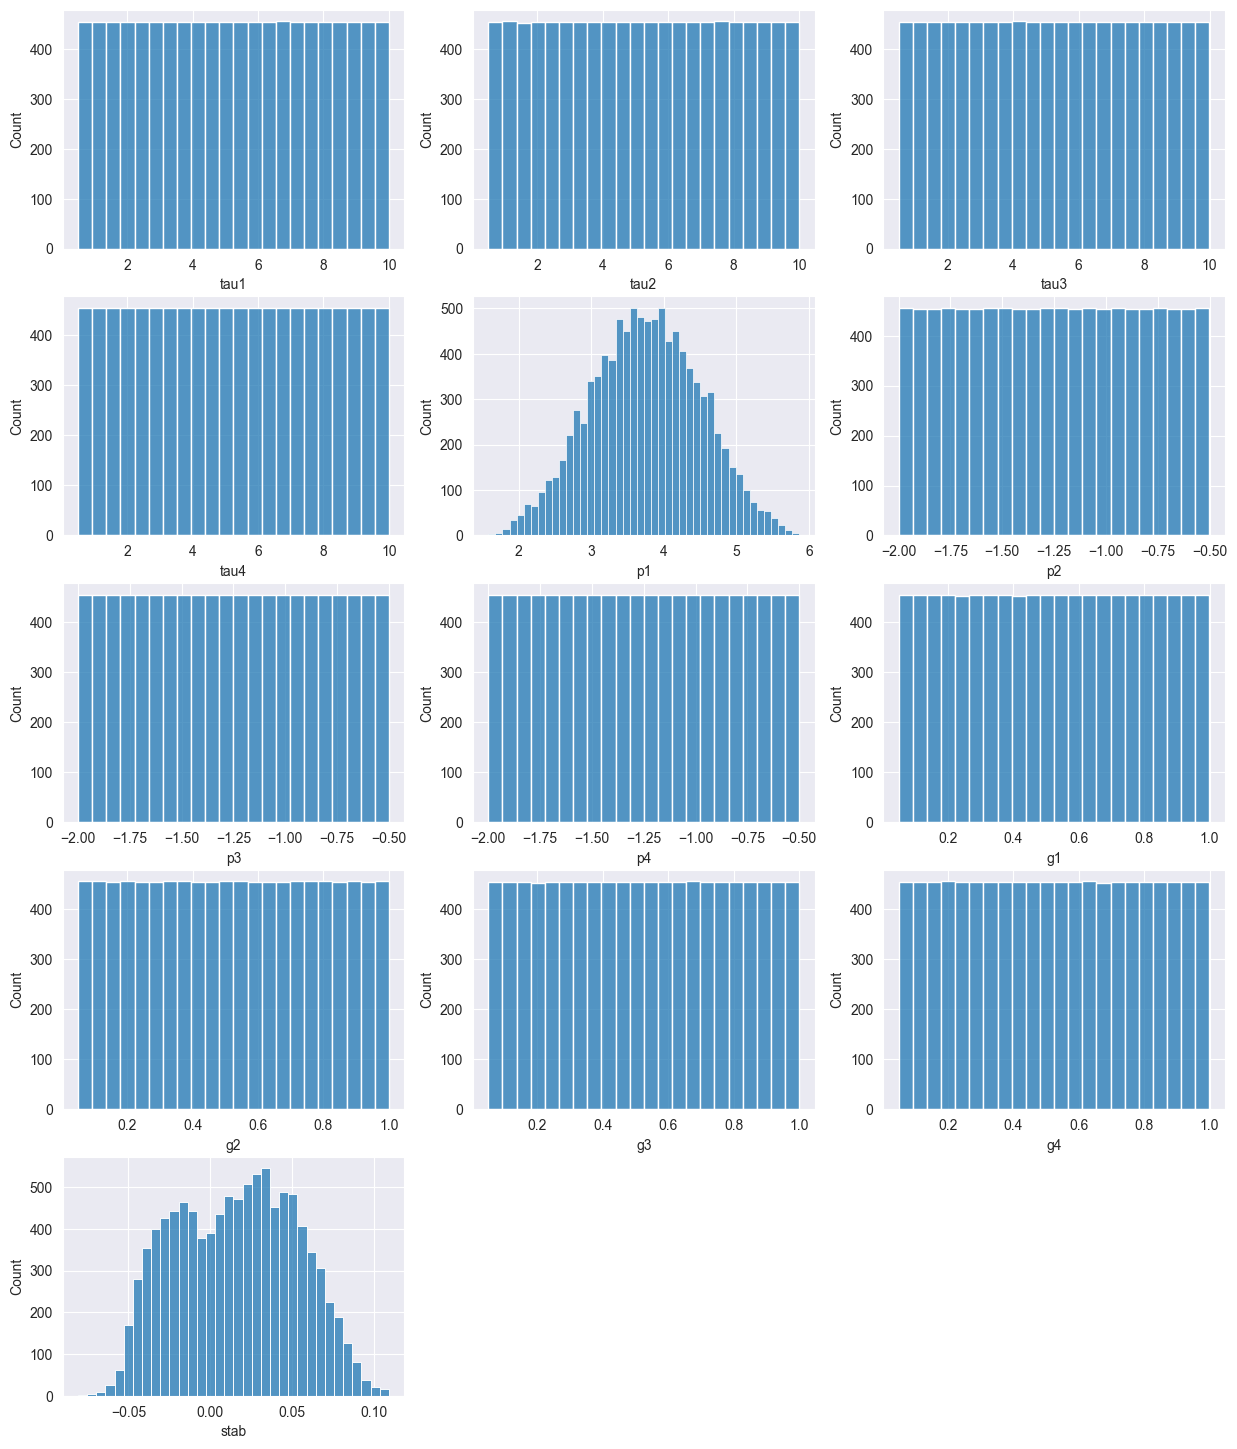

In [6]:
numeric_columns = data.select_dtypes(include=['number']).columns
plt.subplots_adjust(wspace=0.9, hspace=0.9)
fig, ax = plt.subplots(5, 3, figsize=(15, 18))
axes = ax.flatten()
for ax, column in zip(axes, numeric_columns):
    sns.histplot(data=data[column], ax=ax)


axes[-1].set_visible(False)
axes[-2].set_visible(False)

Время реакции участка для производителя и потребителей (`tau1`, `tau2`, `tau3` и `tau4`) распределено равномерно и лежит в диапазоне от 0 до 10.

Мощности потребителей (`p2`, `p3`, `p4`) распределены равномерно и лежат в диапазоне от -2 до -0.5.

Ценовая эластичность (`g1`, `g2`, `g3`, `g4`) для производителя и потребителей распределена равномерно и лежит в диапазоне от 0 до 1.

Мощность производителя (`p1`) имеет распределение, очень близкое к нормальному. Лежит в диапазоне от 1.6 до 5.9.

Так как значение медианы для `stab `равно 0.017, то можно сказать, что более, чем в половине зафиксированных случаев, система является нестабильной.

### Анализ выбросов

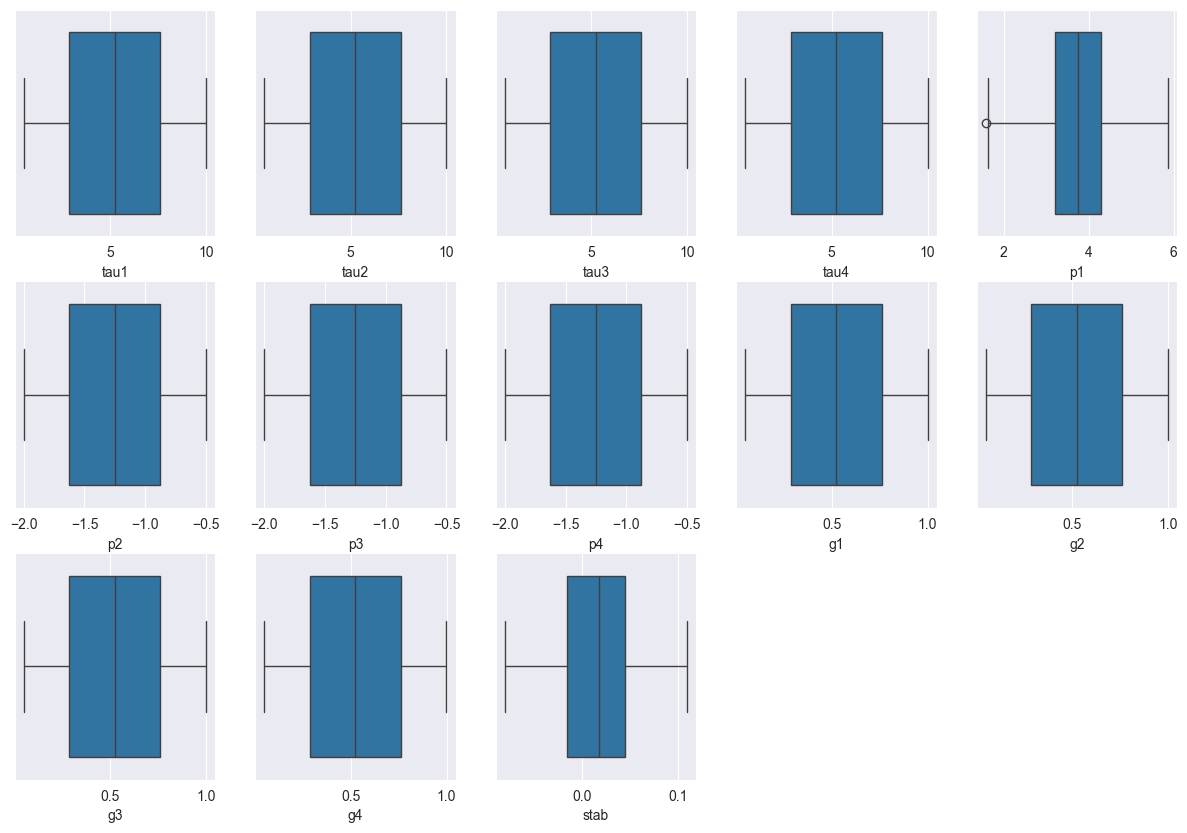

In [7]:
numeric_columns = data.select_dtypes(include=['number']).columns
fig, ax = plt.subplots(3, 5, figsize=(15, 10))
axes = ax.flatten()
for ax, column in zip(axes, numeric_columns):
    sns.boxplot(x = data[column], ax=ax)

axes[-1].set_visible(False)
axes[-2].set_visible(False)

In [8]:
iqr = data["p1"].quantile(0.75) - data["p1"].quantile(0.25)

data[data["p1"] <= 1.5 * iqr]

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
6273,6.698111,7.861157,9.33348,2.433936,1.58259,-0.503865,-0.571522,-0.507202,0.641753,0.868178,0.494277,0.410666,0.056923,unstable


Данное значение является аномальным с очень низким уровнем использования мощности, его не стоит удалять.

### Корреляционный анализ

In [9]:
vif_data = pd.DataFrame()

vif_data["VIF"] = [variance_inflation_factor(data[numeric_columns].values, i) for i in range(data[numeric_columns].shape[1])]

vif_data["Features"] = data[numeric_columns].columns

vif_data

C:\Users\stwz13\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,VIF,Features
0,4.565038,tau1
1,4.525881,tau2
2,4.545824,tau3
3,4.487302,tau4
4,inf,p1
5,inf,p2
6,inf,p3
7,inf,p4
8,4.511152,g1
9,4.579036,g2


Заметим, что для `p1`, `p2`, `p3` и `p4` коэффициент VIF принимает значение inf. Это объясняется наличием мультиколлинеарности: `p1` равно абсолютному значению суммы `p2`, `p3` и `p4`.

Переменная `stab` имеет наименьший коэффициент VIF, равный 1.86. Значит, значения данной переменной практически не подвержены мультиколлинеарности

Прочие переменные не подвержены сильной мультиколлинеарности: значения коэффициента VIF для них лежат в интервале от 4.5 до 5.5.

<Axes: >

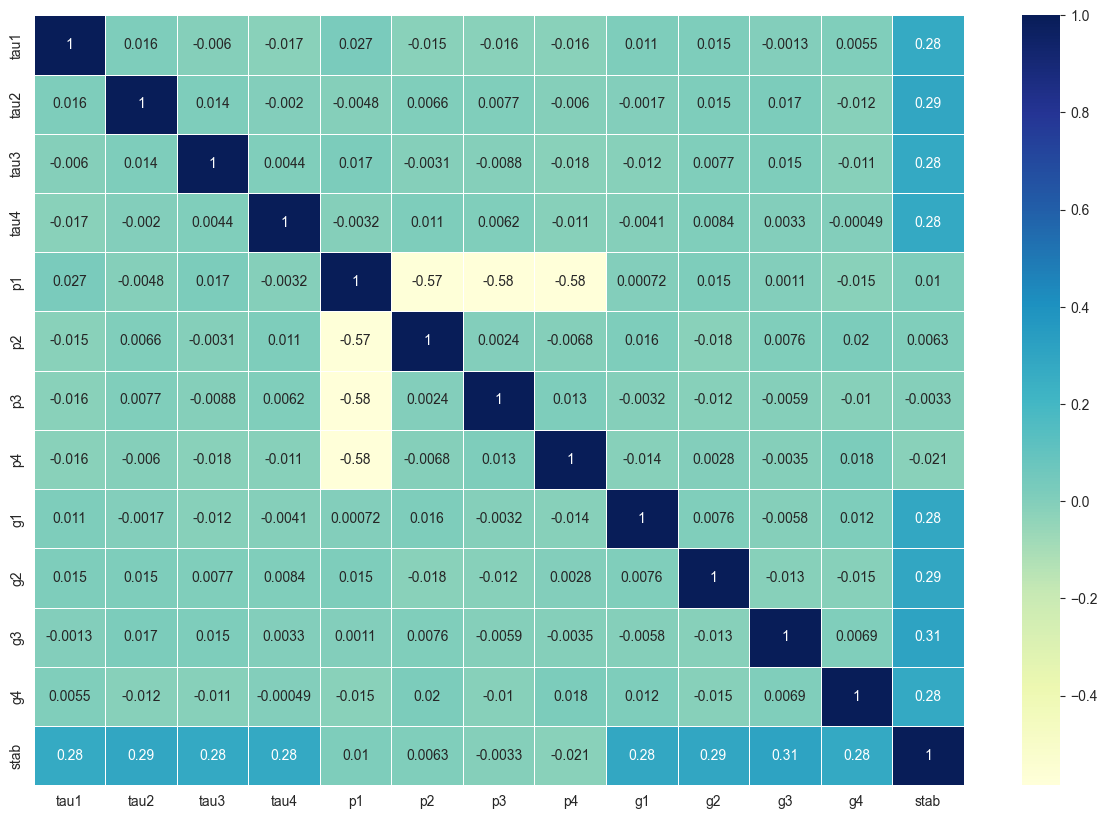

In [10]:
plt.figure(figsize=(15, 10))
sns.heatmap(data.corr(numeric_only = True), annot=True, cmap="YlGnBu", linewidths=.5 )

Средней корреляцией обладает переменная `p1` с признаками `p2`, `p3`, `p4`. Это объясняется тем, что между ними существует прямая линейная зависимость.

Переменная `stab ` обладает слабой корреляцией с `tau1`, `tau2`, `tau3`, `tau4` и `g1`, `g2`, `g3`, `g4`. Значит, устойчивость системы в большей степени определяется временем реакции и ценовой эластичностью, чем потребляемой мощностью.

### Кодирование категориальных признаков

In [11]:
data["stabf"] = data["stabf"].map({"stable": 1, "unstable": 0})

### Масштабирование

In [12]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data[numeric_columns])

scaled_df = pd.DataFrame(scaled_data, index=data[numeric_columns].index, columns=data[numeric_columns].columns)
scaled_df = pd.concat([scaled_df, data["stabf"]], axis=1)

## Обучение модели регрессии

Прежде, чем приступить к обучению моделей, сделаем несколько вспомогательных инструментов для избежания дублирования кода.

Функция `get_metrics` возвращает список из рассчитанных метрических показателей для предсказанных и истинных значений.

In [13]:
def get_metrics(y_test, y_predicted, print_results=False):
    names_of_metrics = ["R2", "MSE", "RMSE", "MAE", "MAPE"]
    results = [
        round(r2_score(y_test, y_predicted), 2),
        round(mean_squared_error(y_test, y_predicted), 4),
        round(root_mean_squared_error(y_test, y_predicted), 4),
        round(mean_absolute_error(y_test, y_predicted), 4),
        round(mean_absolute_percentage_error(y_test, y_predicted), 4)
    ]

    if print_results:
        for name, result in zip(names_of_metrics, results):
            print(f"{name}: {result}")

    return results

Функция `input_into_the_tables` будет использоваться для вставки полученных значений метрик в результирующую таблицу со всеми моделями.

In [14]:
def input_metrics_into_the_table(name_of_model,
                                 predict_on_train_y, y_train,
                                 predict_on_val_y, y_val,
                                 predict_on_test_y, y_test,
                                 train_val_test_comparing):
    test_metrics = get_metrics(y_test, predict_on_test_y)

    val_metrics = get_metrics(y_val, predict_on_val_y)

    train_metrics = get_metrics(y_train, predict_on_train_y)

    train_val_test_comparing.loc[name_of_model] = train_metrics + val_metrics + test_metrics

Функция `train_models_with_reg` обучает модели с L1, L2 и ElasticNet регуляризациями с использованием GridSearch, RandomSearch, Optuna и возвращает полученные модели в словаре.

In [15]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

def train_models_with_reg(X_train, y_train, X_val, y_val, reg_config):

    result={}

    for name, reg_info in reg_config.items():

        param_grid = reg_info["param_grid"]
        type_of_reg = reg_info["reg"]

        grid_search_model = GridSearchCV(
            param_grid=param_grid,
            estimator=type_of_reg(max_iter=1000),
            scoring="neg_mean_squared_error",
            cv=3
        )

        grid_search_model.fit(X_train, y_train)

        random_search_model = RandomizedSearchCV(
            param_distributions=param_grid,
            estimator=type_of_reg(max_iter=1000),
            scoring="neg_mean_squared_error",
            random_state=42,
            cv=3
        )

        random_search_model.fit(X_train, y_train)

        def objective(trial):
            trial_params = {}
            for p_name, p_values in param_grid.items():
                if isinstance(p_values[0], float):
                    trial_params[p_name] = trial.suggest_float(p_name, min(p_values), max(p_values), log=True)
                else:
                    trial_params[p_name] = trial.suggest_categorical(p_name, p_values)

            model = type_of_reg(**trial_params)
            model.fit(X_train, y_train)
            val_predict = model.predict(X_val)
            return mean_squared_error(y_val, val_predict)

        study = optuna.create_study(direction='minimize')
        study.optimize(objective, n_trials=100, show_progress_bar=False)

        optuna_model = type_of_reg(**study.best_params)
        optuna_model.fit(X_train, y_train)

        result[name] = {}
        result[name]["GridSearch"] = {
            "model": grid_search_model.best_estimator_,
            "best_params": grid_search_model.best_params_
        }
        result[name]["RandomSearch"] = {
            "model": random_search_model.best_estimator_,
            "best_params": random_search_model.best_params_
        }
        result[name]["Optuna"] = {
            "model": optuna_model,
            "best_params": study.best_params
        }

    return result


Ниже происходит создание датафрейма для хранения метрик.

In [16]:
metrics = ["R2", "MSE", "RMSE", "MAE", "MAPE"]

columns = pd.MultiIndex.from_product([
    ["Train Data", "Val Data", "Test Data"],
    metrics
])

train_and_test_comparing = pd.DataFrame(columns=columns)

train_and_test_comparing

Empty DataFrame
Columns: [(Train Data, R2), (Train Data, MSE), (Train Data, RMSE), (Train Data, MAE), (Train Data, MAPE), (Val Data, R2), (Val Data, MSE), (Val Data, RMSE), (Val Data, MAE), (Val Data, MAPE), (Test Data, R2), (Test Data, MSE), (Test Data, RMSE), (Test Data, MAE), (Test Data, MAPE)]
Index: []

Разделение выборки на обучающую, валидационную и тестовую

In [17]:
X = scaled_df.drop("stab", axis=1)
y = scaled_df["stab"]

X_train, X_val_test, y_train, y_val_test = train_test_split(X, y, test_size=0.2, random_state=13)

X_val, X_test, y_val, y_test = train_test_split(X_val_test, y_val_test, test_size=0.5)

print(f"Общее количество объектов: {len(X)}\n"
      f"Количество данных в валидационной выборке {len(X_val)}\n"
      f"Количество данных в тестовой выборке {len(X_test)}\n")



Общее количество объектов: 10000
Количество данных в валидационной выборке 1000
Количество данных в тестовой выборке 1000



Для начала обучим модель множественной регрессии без регуляризации.

### Множественная регрессия без регуляризации

In [18]:
simple_model = LinearRegression()
simple_model.fit(X_train, y_train)

simple_model.coef_

array([ 1.43677936e-01,  1.53279556e-01,  1.52705968e-01,  1.50725576e-01,
        1.83224341e-03, -2.66862035e-03, -1.31621955e-04, -3.82273622e-04,
        1.73497526e-01,  1.73622285e-01,  1.84468149e-01,  1.71695472e-01,
       -1.11991569e+00])

In [20]:
simple_model_train_predict = simple_model.predict(X_train)
simple_model_val_predict = simple_model.predict(X_val)
simple_model_test_predict = simple_model.predict(X_test)

input_metrics_into_the_table(
    "Linear regression without regularization",
    simple_model_train_predict, y_train,
    simple_model_val_predict, y_val,
    simple_model_test_predict, y_test,
    train_and_test_comparing
)

train_and_test_comparing.loc["Linear regression without regularization"]

Train Data  R2      0.8200
            MSE     0.1847
            RMSE    0.4298
            MAE     0.3434
            MAPE    1.9705
Val Data    R2      0.8100
            MSE     0.1874
            RMSE    0.4330
            MAE     0.3434
            MAPE    1.8730
Test Data   R2      0.8100
            MSE     0.1834
            RMSE    0.4282
            MAE     0.3419
            MAPE    4.1856
Name: Linear regression without regularization, dtype: float64

Модель работает практически одинаково хорошо на тренировочной и тестовой выборках. Попробуем применить регуляризацию для модели.

<Axes: ylabel='stab'>

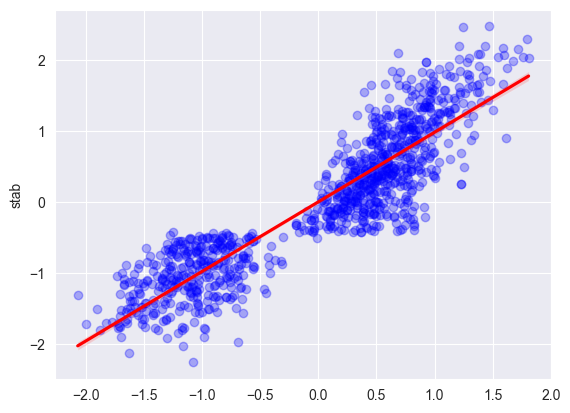

In [21]:
sns.regplot(x = simple_model_test_predict, y=y_test, line_kws={"color": "r"}, scatter_kws={"color": "b", "alpha": 0.3})

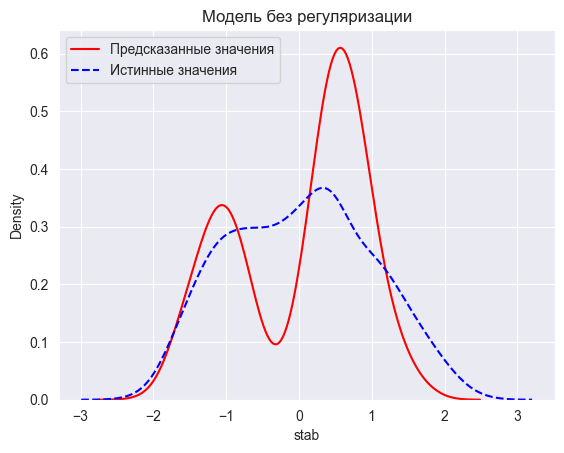

In [22]:
sns.kdeplot(simple_model_test_predict, label="Предсказанные значения", color="red")
sns.kdeplot(y_test, label="Истинные значения", color="blue", linestyle="--")

plt.title("Модель без регуляризации")
plt.legend()

### Множественная регрессия с регуляризацией

Для начала с помощью кастомной функции получим модели с видами регуляризаций L1, L2, ElasticNet. В дальнейшем рассмотрим каждый вид регуляризации отдельно.

In [24]:
alpha_range = np.logspace(-3, 2).tolist()
reg_config = {
    "L1": {
        "reg": Lasso,
        "param_grid": {"alpha": alpha_range}
    },
    "L2":
        {
            "reg": Ridge,
            "param_grid": {"alpha": alpha_range}
        },
    "EN":
        {
            "reg": ElasticNet,
            "param_grid":{
                    "alpha": alpha_range,
                    "l1_ratio": np.arange(0.1, 1, 0.3).tolist()
            }

        }

}
models_with_regularization = train_models_with_reg(X_train, y_train, X_val, y_val, reg_config)

#### L1 регуляризация

In [25]:
l1_models = models_with_regularization["L1"]
names = ["GridSearch", "RandomSearch", "Optuna"]

for name, model_dict in zip(names, l1_models.values()):
    print(f"Способ подбора параметров: {name}")
    print(model_dict["best_params"])


Способ подбора параметров: GridSearch
{'alpha': 0.0032374575428176433}
Способ подбора параметров: RandomSearch
{'alpha': 0.021209508879201904}
Способ подбора параметров: Optuna
{'alpha': 0.006827454913516966}


Видим, что оптимальные параметры получились примерно одинаковыми с точностью до 5 знаков после запятой. Попробуем использовать модель с параметрами, вычисленными GridSearch.

In [26]:
l1_multiple_model = l1_models["GridSearch"]["model"]

l1_multiple_model.coef_

array([ 1.40992760e-01,  1.50440485e-01,  1.49937637e-01,  1.47841340e-01,
        4.43517257e-04, -8.03314209e-05, -0.00000000e+00, -0.00000000e+00,
        1.70579090e-01,  1.70952079e-01,  1.81582822e-01,  1.68725799e-01,
       -1.11646080e+00])

В результате применения Lasso-регуляризации значения весов уменьшились. Некоторые из весов обратились в ноль из-за наличия мультиколлинеарности.

In [29]:
l1_multiple_model_train_predict = l1_multiple_model.predict(X_train)
l1_multiple_model_val_predict = l1_multiple_model.predict(X_val)
l1_multiple_model_test_predict = l1_multiple_model.predict(X_test)

input_metrics_into_the_table(
    "Linear regression with Lasso regularization",
    l1_multiple_model_train_predict, y_train,
    l1_multiple_model_test_predict, y_test,
    l1_multiple_model_val_predict, y_val,
    train_and_test_comparing
)

train_and_test_comparing.loc["Linear regression with Lasso regularization"]

Train Data  R2      0.8200
            MSE     0.1848
            RMSE    0.4299
            MAE     0.3438
            MAPE    1.9668
Val Data    R2      0.8100
            MSE     0.1833
            RMSE    0.4281
            MAE     0.3419
            MAPE    4.1546
Test Data   R2      0.8100
            MSE     0.1869
            RMSE    0.4324
            MAE     0.3434
            MAPE    1.8651
Name: Linear regression with Lasso regularization, dtype: float64

В результате применения L1-регуляризации показатели метрик практически не изменились.

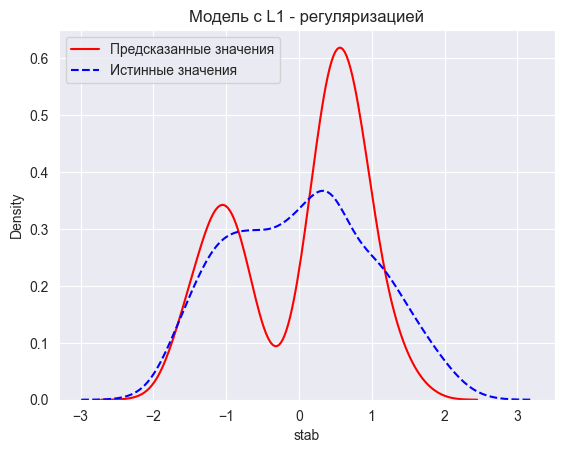

In [30]:
sns.kdeplot(l1_multiple_model_test_predict, label="Предсказанные значения", color="red")
sns.kdeplot(y_test, label="Истинные значения", color="blue", linestyle="--")

plt.title("Модель с L1 - регуляризацией")
plt.legend()

#### L2 регуляризация

In [31]:
l2_models = models_with_regularization["L2"]
names = ["GridSearch", "RandomSearch", "Optuna"]

for name, model_dict in zip(names, l2_models.values()):
    print(f"Способ подбора параметров: {name}")
    print(model_dict["best_params"])

Способ подбора параметров: GridSearch
{'alpha': 0.001}
Способ подбора параметров: RandomSearch
{'alpha': 0.021209508879201904}
Способ подбора параметров: Optuna
{'alpha': 48.026775762498374}


Фреймворк Optuna показал в качестве результата наибольшее значение гиперпараметра. Попробуем применить эти результаты в модели.

In [32]:
l2_multiple_model = l2_models["Optuna"]["model"]

print(simple_model.coef_, l2_multiple_model.coef_, sep="\n")

[ 1.43677936e-01  1.53279556e-01  1.52705968e-01  1.50725576e-01
  1.83224341e-03 -2.66862035e-03 -1.31621955e-04 -3.82273622e-04
  1.73497526e-01  1.73622285e-01  1.84468149e-01  1.71695472e-01
 -1.11991569e+00]
[ 1.47387722e-01  1.56912884e-01  1.56379360e-01  1.54463286e-01
  1.78932396e-03 -2.48293928e-03  5.59340236e-06 -6.30621095e-04
  1.76322531e-01  1.76897217e-01  1.87765941e-01  1.74661165e-01
 -1.07912475e+00]


Заметим, что веса модели с L2 регуляризацией немного уменьшились в сравнении с весами модели без регуляризации.

In [33]:
l2_multiple_model_train_predict = l2_multiple_model.predict(X_train)
l2_multiple_model_val_predict = l2_multiple_model.predict(X_val)
l2_multiple_model_test_predict = l2_multiple_model.predict(X_test)

input_metrics_into_the_table(
    "Linear regression with Ridge regularization",
    l2_multiple_model_train_predict, y_train,
    l2_multiple_model_val_predict, y_val,
    l2_multiple_model_test_predict, y_test,
    train_and_test_comparing
)
train_and_test_comparing

Train Data                  \
                                                    R2     MSE    RMSE   
Linear regression without regularization          0.82  0.1847  0.4298   
Linear regression with Lasso regularization       0.82  0.1848  0.4299   
Linear regression with Ridge regularization       0.82  0.1849  0.4301   

                                                            Val Data          \
                                                MAE    MAPE       R2     MSE   
Linear regression without regularization     0.3434  1.9705     0.81  0.1874   
Linear regression with Lasso regularization  0.3438  1.9668     0.81  0.1833   
Linear regression with Ridge regularization  0.3434  1.9159     0.81  0.1872   

                                                                    Test Data  \
                                               RMSE     MAE    MAPE        R2   
Linear regression without regularization     0.4330  0.3434  1.8730      0.81   
Linear regression with Lasso regularization  0.4281  0.3419  4.1546      0.81   
Linear regression with Ridge regularization  0.4327  0.3428  1.8278      0.81   

                                                                             
                                                MSE    RMSE     MAE    MAPE  
Linear regression without regularization     0.1834  0.4282  0.3419  4.1856  
Linear regression with Lasso regularization  0.1869  0.4324  0.3434  1.8651  
Linear regression with Ridge regularization  0.1825  0.4272  0.3396  4.0870

Модели с Lasso и Ridge регуляризациями в целом показывают одинаковые результаты. Их отличие лишь в метрике MAPE как для валидационных и тестовых, так и для обучающих данных - в L2 регуляризации эта метрика уменьшилась.

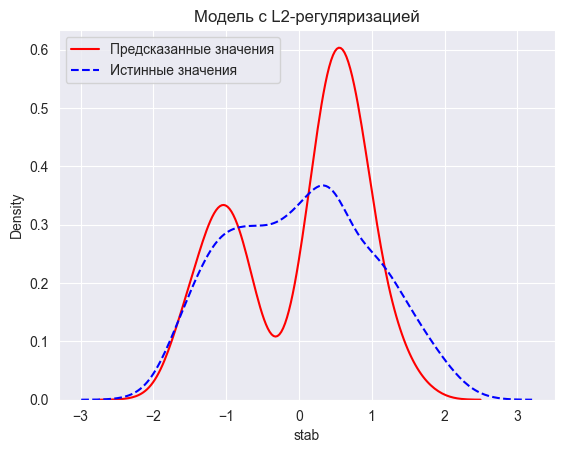

In [34]:
sns.kdeplot(l2_multiple_model_test_predict, label="Предсказанные значения", color="red")
sns.kdeplot(y_test, label="Истинные значения", color="blue", linestyle="--")

plt.title("Модель с L2-регуляризацией")
plt.legend()

#### Elastic Net регуляризация

In [35]:
elastic_net_multiple_models = models_with_regularization["EN"]

for name, model_dict in zip(names, elastic_net_multiple_models.values()):
    print(f"Способ подбора параметров: {name}")
    print(model_dict["best_params"])


Способ подбора параметров: GridSearch
{'alpha': 0.004094915062380427, 'l1_ratio': 0.7000000000000001}
Способ подбора параметров: RandomSearch
{'l1_ratio': 0.1, 'alpha': 0.004094915062380427}
Способ подбора параметров: Optuna
{'alpha': 0.008947635898257563, 'l1_ratio': 0.6559491654819412}


Заметим, что Optuna и GridSearch показали примерно одинаковые результаты для параметров `alpha`. Попробуем получить предсказания с помощью полученных моделей и посмотрим на метрики.

Train Data                  \
                                                           R2     MSE    RMSE   
Linear regression without regularization                 0.82  0.1847  0.4298   
Linear regression with Lasso regularization              0.82  0.1848  0.4299   
Linear regression with Ridge regularization              0.82  0.1849  0.4301   
Linear regression with Elastic Net (get with Gr...       0.82  0.1848  0.4299   
Linear regression with Elastic Net (get with Ra...       0.82  0.1848  0.4299   
Linear regression with Elastic Net (get with Op...       0.82  0.1851  0.4303   

                                                                   Val Data  \
                                                       MAE    MAPE       R2   
Linear regression without regularization            0.3434  1.9705     0.81   
Linear regression with Lasso regularization         0.3438  1.9668     0.81   
Linear regression with Ridge regularization         0.3434  1.9159     0.81   
Linear regression with Elastic Net (get with Gr...  0.3437  1.9552     0.81   
Linear regression with Elastic Net (get with Ra...  0.3434  1.9355     0.81   
Linear regression with Elastic Net (get with Op...  0.3441  1.9321     0.81   

                                                                            \
                                                       MSE    RMSE     MAE   
Linear regression without regularization            0.1874  0.4330  0.3434   
Linear regression with Lasso regularization         0.1833  0.4281  0.3419   
Linear regression with Ridge regularization         0.1872  0.4327  0.3428   
Linear regression with Elastic Net (get with Gr...  0.1831  0.4279  0.3413   
Linear regression with Elastic Net (get with Ra...  0.1828  0.4275  0.3404   
Linear regression with Elastic Net (get with Op...  0.1829  0.4277  0.3408   

                                                           Test Data          \
                                                      MAPE        R2     MSE   
Linear regression without regularization            1.8730      0.81  0.1834   
Linear regression with Lasso regularization         4.1546      0.81  0.1869   
Linear regression with Ridge regularization         1.8278      0.81  0.1825   
Linear regression with Elastic Net (get with Gr...  4.1374      0.81  0.1869   
Linear regression with Elastic Net (get with Ra...  4.1214      0.81  0.1872   
Linear regression with Elastic Net (get with Op...  4.0830      0.81  0.1867   

                                                                            
                                                      RMSE     MAE    MAPE  
Linear regression without regularization            0.4282  0.3419  4.1856  
Linear regression with Lasso regularization         0.4324  0.3434  1.8651  
Linear regression with Ridge regularization         0.4272  0.3396  4.0870  
Linear regression with Elastic Net (get with Gr...  0.4324  0.3432  1.8562  
Linear regression with Elastic Net (get with Ra...  0.4327  0.3430  1.8434  
Linear regression with Elastic Net (get with Op...  0.4321  0.3434  1.8346

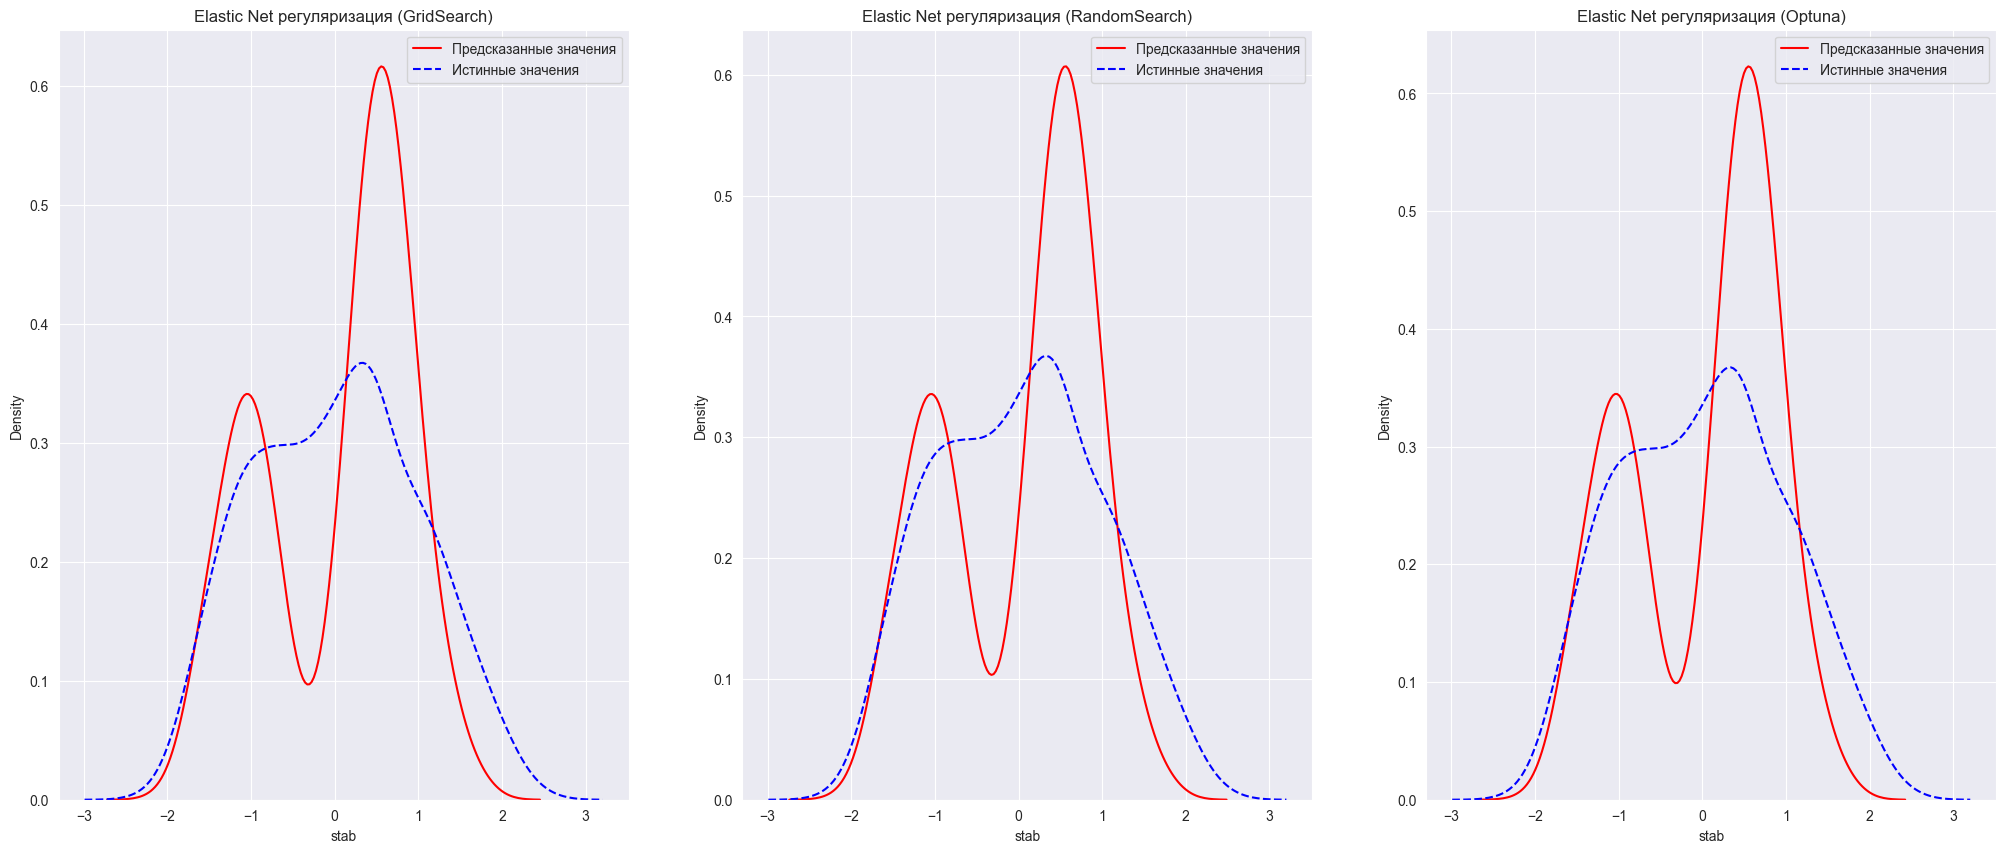

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(25, 10))

for name, ax in zip(names, axes):
    model = elastic_net_multiple_models[name]["model"]

    train_predict = model.predict(X_train)
    val_predict = model.predict(X_val)
    test_predict = model.predict(X_test)

    sns.kdeplot(test_predict, ax=ax, label="Предсказанные значения", color="red")
    sns.kdeplot(y_test, ax=ax, label="Истинные значения", color="blue", linestyle="--")
    ax.set_title(f"Elastic Net регуляризация ({name})")
    ax.legend()

    input_metrics_into_the_table(
        f"Linear regression with Elastic Net (get with {name})",
        train_predict, y_train,
        test_predict, y_test,
        val_predict, y_val,
        train_and_test_comparing
    )

train_and_test_comparing

Видим, что Elastic Net регуляризация с разными параметрами практически никак не повлияла на значения метрик

### Полиномиальная регрессия без регуляризации

Для начала используем модель с полиномом 2 степени.

#### Полиномиальная регрессия второй степени

In [40]:
poly = PolynomialFeatures(degree = 2)
X_poly2_train = poly.fit_transform(X_train)
X_poly2_test = poly.transform(X_test)
X_poly2_val = poly.fit_transform(X_val)

X_poly2_train.shape

(8000, 105)

In [41]:
model = LinearRegression()
model.fit(X_poly2_train, y_train)

train_predict = model.predict(X_poly2_train)
val_predict = model.predict(X_poly2_val)
test_predict = model.predict(X_poly2_test)

input_metrics_into_the_table(
    f"Polynomial regression (deg 2) without regularization",
    train_predict, y_train,
    val_predict, y_test,
    test_predict, y_test,
    train_and_test_comparing
)

train_and_test_comparing

Train Data                  \
                                                           R2     MSE    RMSE   
Linear regression without regularization                 0.82  0.1847  0.4298   
Linear regression with Lasso regularization              0.82  0.1848  0.4299   
Linear regression with Ridge regularization              0.82  0.1849  0.4301   
Linear regression with Elastic Net (get with Gr...       0.82  0.1848  0.4299   
Linear regression with Elastic Net (get with Ra...       0.82  0.1848  0.4299   
Linear regression with Elastic Net (get with Op...       0.82  0.1851  0.4303   
Polynomial regression (deg 2) without regulariz...       0.93  0.0731  0.2704   

                                                                   Val Data  \
                                                       MAE    MAPE       R2   
Linear regression without regularization            0.3434  1.9705     0.81   
Linear regression with Lasso regularization         0.3438  1.9668     0.81   
Linear regression with Ridge regularization         0.3434  1.9159     0.81   
Linear regression with Elastic Net (get with Gr...  0.3437  1.9552     0.81   
Linear regression with Elastic Net (get with Ra...  0.3434  1.9355     0.81   
Linear regression with Elastic Net (get with Op...  0.3441  1.9321     0.81   
Polynomial regression (deg 2) without regulariz...  0.2050  1.0557    -0.93   

                                                                            \
                                                       MSE    RMSE     MAE   
Linear regression without regularization            0.1874  0.4330  0.3434   
Linear regression with Lasso regularization         0.1833  0.4281  0.3419   
Linear regression with Ridge regularization         0.1872  0.4327  0.3428   
Linear regression with Elastic Net (get with Gr...  0.1831  0.4279  0.3413   
Linear regression with Elastic Net (get with Ra...  0.1828  0.4275  0.3404   
Linear regression with Elastic Net (get with Op...  0.1829  0.4277  0.3408   
Polynomial regression (deg 2) without regulariz...  1.8431  1.3576  1.1044   

                                                            Test Data          \
                                                       MAPE        R2     MSE   
Linear regression without regularization             1.8730      0.81  0.1834   
Linear regression with Lasso regularization          4.1546      0.81  0.1869   
Linear regression with Ridge regularization          1.8278      0.81  0.1825   
Linear regression with Elastic Net (get with Gr...   4.1374      0.81  0.1869   
Linear regression with Elastic Net (get with Ra...   4.1214      0.81  0.1872   
Linear regression with Elastic Net (get with Op...   4.0830      0.81  0.1867   
Polynomial regression (deg 2) without regulariz...  10.7102      0.92  0.0738   

                                                                            
                                                      RMSE     MAE    MAPE  
Linear regression without regularization            0.4282  0.3419  4.1856  
Linear regression with Lasso regularization         0.4324  0.3434  1.8651  
Linear regression with Ridge regularization         0.4272  0.3396  4.0870  
Linear regression with Elastic Net (get with Gr...  0.4324  0.3432  1.8562  
Linear regression with Elastic Net (get with Ra...  0.4327  0.3430  1.8434  
Linear regression with Elastic Net (get with Op...  0.4321  0.3434  1.8346  
Polynomial regression (deg 2) without regulariz...  0.2718  0.2069  1.6802

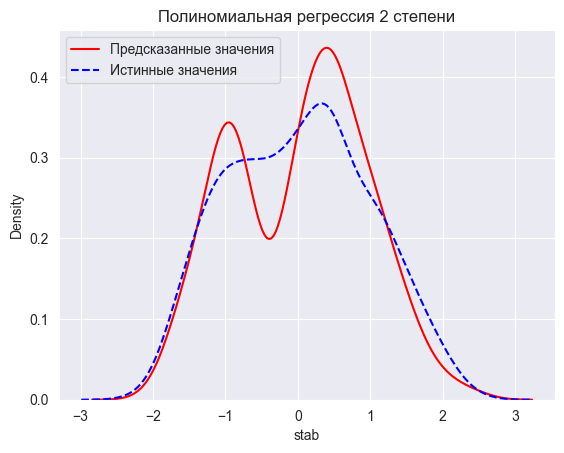

In [42]:
sns.kdeplot(test_predict, label="Предсказанные значения", color="red")
sns.kdeplot(y_test, label="Истинные значения", color="blue", linestyle="--")
plt.title("Полиномиальная регрессия 2 степени")
plt.legend()

Видимо, что модель полиномиальной регрессии 2 степени показала лучшие результаты, чем предыдущие модели. Значения метрик улучшились: коэффициент R2 увеличился на тестовой и тренировочной выборках. Значения метрик MSE, RMSE, MAE, MAPE уменьшились.

На графике видно, что распределение предсказаний этой модели стало ближе к распределению истинных значений в сравнении с предыдущими моделями.


#### Полиномиальная регрессия 3 степени

In [44]:
poly3 = PolynomialFeatures(degree=3)

X_poly3_train = poly3.fit_transform(X_train)
X_poly3_val = poly3.transform(X_val)
X_poly3_test = poly3.transform(X_test)

X_poly3_train.shape

(8000, 560)

In [46]:
model = LinearRegression()
model.fit(X_poly3_train, y_train)

train_predict = model.predict(X_poly3_train)
val_predict = model.predict(X_poly3_val)
test_predict = model.predict(X_poly3_test)

input_metrics_into_the_table(
    f"Polynomial regression (deg 3) without regularization",
    train_predict, y_train,
    val_predict, y_test,
    test_predict, y_test,
    train_and_test_comparing
)

train_and_test_comparing

Train Data                  \
                                                           R2     MSE    RMSE   
Linear regression without regularization                 0.82  0.1847  0.4298   
Linear regression with Lasso regularization              0.82  0.1848  0.4299   
Linear regression with Ridge regularization              0.82  0.1849  0.4301   
Linear regression with Elastic Net (get with Gr...       0.82  0.1848  0.4299   
Linear regression with Elastic Net (get with Ra...       0.82  0.1848  0.4299   
Linear regression with Elastic Net (get with Op...       0.82  0.1851  0.4303   
Polynomial regression (deg 2) without regulariz...       0.93  0.0731  0.2704   
Polynomial regression (deg 3) without regulariz...       0.97  0.0339  0.1842   

                                                                   Val Data  \
                                                       MAE    MAPE       R2   
Linear regression without regularization            0.3434  1.9705     0.81   
Linear regression with Lasso regularization         0.3438  1.9668     0.81   
Linear regression with Ridge regularization         0.3434  1.9159     0.81   
Linear regression with Elastic Net (get with Gr...  0.3437  1.9552     0.81   
Linear regression with Elastic Net (get with Ra...  0.3434  1.9355     0.81   
Linear regression with Elastic Net (get with Op...  0.3441  1.9321     0.81   
Polynomial regression (deg 2) without regulariz...  0.2050  1.0557    -0.93   
Polynomial regression (deg 3) without regulariz...  0.1288  0.5989    -0.94   

                                                                            \
                                                       MSE    RMSE     MAE   
Linear regression without regularization            0.1874  0.4330  0.3434   
Linear regression with Lasso regularization         0.1833  0.4281  0.3419   
Linear regression with Ridge regularization         0.1872  0.4327  0.3428   
Linear regression with Elastic Net (get with Gr...  0.1831  0.4279  0.3413   
Linear regression with Elastic Net (get with Ra...  0.1828  0.4275  0.3404   
Linear regression with Elastic Net (get with Op...  0.1829  0.4277  0.3408   
Polynomial regression (deg 2) without regulariz...  1.8431  1.3576  1.1044   
Polynomial regression (deg 3) without regulariz...  1.8467  1.3589  1.1100   

                                                            Test Data          \
                                                       MAPE        R2     MSE   
Linear regression without regularization             1.8730      0.81  0.1834   
Linear regression with Lasso regularization          4.1546      0.81  0.1869   
Linear regression with Ridge regularization          1.8278      0.81  0.1825   
Linear regression with Elastic Net (get with Gr...   4.1374      0.81  0.1869   
Linear regression with Elastic Net (get with Ra...   4.1214      0.81  0.1872   
Linear regression with Elastic Net (get with Op...   4.0830      0.81  0.1867   
Polynomial regression (deg 2) without regulariz...  10.7102      0.92  0.0738   
Polynomial regression (deg 3) without regulariz...   9.7181      0.96  0.0370   

                                                                            
                                                      RMSE     MAE    MAPE  
Linear regression without regularization            0.4282  0.3419  4.1856  
Linear regression with Lasso regularization         0.4324  0.3434  1.8651  
Linear regression with Ridge regularization         0.4272  0.3396  4.0870  
Linear regression with Elastic Net (get with Gr...  0.4324  0.3432  1.8562  
Linear regression with Elastic Net (get with Ra...  0.4327  0.3430  1.8434  
Linear regression with Elastic Net (get with Op...  0.4321  0.3434  1.8346  
Polynomial regression (deg 2) without regulariz...  0.2718  0.2069  1.6802  
Polynomial regression (deg 3) without regulariz...  0.1924  0.1363  0.8215

Полином 3 степени дал лучшие значения метрик, чем полином 2 степени. Значение коэффициента R2 увеличилось, а значения прочих метрик уменьшились. Кроме того, значения метрик на тренировочной выборке лучше, чем значения метрик на тестовой выборке. Так, MAPE на тренировочной выборке равен 0.577, а на тестовой 0.652. Это говорит о том, что возможно переобучение модели.

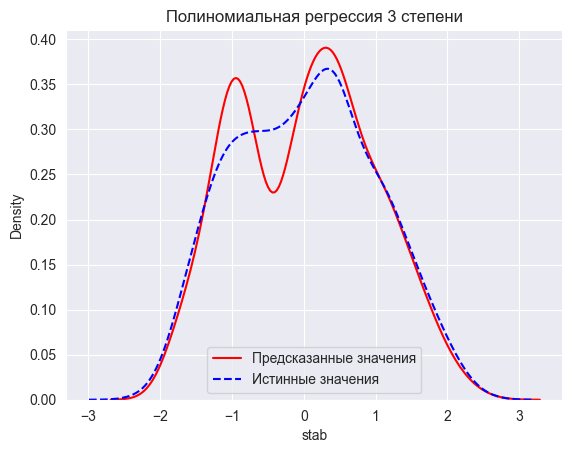

In [47]:
sns.kdeplot(test_predict, label="Предсказанные значения", color="red")
sns.kdeplot(y_test, label="Истинные значения", color="blue", linestyle="--")
plt.title("Полиномиальная регрессия 3 степени")
plt.legend()

По графику распределения видно, что предсказанные значения стали ближе к истинным.

#### Полиномиальная регрессия 4 степени

In [48]:
poly4 = PolynomialFeatures(degree=4)

X_poly4_train = poly4.fit_transform(X_train)
X_poly4_val = poly4.transform(X_val)
X_poly4_test = poly4.transform(X_test)

X_poly4_train.shape

(8000, 2380)

In [49]:
model = LinearRegression()
model.fit(X_poly4_train, y_train)

train_predict = model.predict(X_poly4_train)
val_predict = model.predict(X_poly4_val)
test_predict = model.predict(X_poly4_test)

input_metrics_into_the_table(
    f"Polynomial regression (deg 4) without regularization",
    train_predict, y_train,
    val_predict, y_val,
    test_predict, y_test,
    train_and_test_comparing
)

train_and_test_comparing

Train Data                  \
                                                           R2     MSE    RMSE   
Linear regression without regularization                 0.82  0.1847  0.4298   
Linear regression with Lasso regularization              0.82  0.1848  0.4299   
Linear regression with Ridge regularization              0.82  0.1849  0.4301   
Linear regression with Elastic Net (get with Gr...       0.82  0.1848  0.4299   
Linear regression with Elastic Net (get with Ra...       0.82  0.1848  0.4299   
Linear regression with Elastic Net (get with Op...       0.82  0.1851  0.4303   
Polynomial regression (deg 2) without regulariz...       0.93  0.0731  0.2704   
Polynomial regression (deg 3) without regulariz...       0.97  0.0339  0.1842   
Polynomial regression (deg 4) without regulariz...       0.98  0.0186  0.1362   

                                                                   Val Data  \
                                                       MAE    MAPE       R2   
Linear regression without regularization            0.3434  1.9705     0.81   
Linear regression with Lasso regularization         0.3438  1.9668     0.81   
Linear regression with Ridge regularization         0.3434  1.9159     0.81   
Linear regression with Elastic Net (get with Gr...  0.3437  1.9552     0.81   
Linear regression with Elastic Net (get with Ra...  0.3434  1.9355     0.81   
Linear regression with Elastic Net (get with Op...  0.3441  1.9321     0.81   
Polynomial regression (deg 2) without regulariz...  0.2050  1.0557    -0.93   
Polynomial regression (deg 3) without regulariz...  0.1288  0.5989    -0.94   
Polynomial regression (deg 4) without regulariz...  0.0930  0.3560     0.97   

                                                                            \
                                                       MSE    RMSE     MAE   
Linear regression without regularization            0.1874  0.4330  0.3434   
Linear regression with Lasso regularization         0.1833  0.4281  0.3419   
Linear regression with Ridge regularization         0.1872  0.4327  0.3428   
Linear regression with Elastic Net (get with Gr...  0.1831  0.4279  0.3413   
Linear regression with Elastic Net (get with Ra...  0.1828  0.4275  0.3404   
Linear regression with Elastic Net (get with Op...  0.1829  0.4277  0.3408   
Polynomial regression (deg 2) without regulariz...  1.8431  1.3576  1.1044   
Polynomial regression (deg 3) without regulariz...  1.8467  1.3589  1.1100   
Polynomial regression (deg 4) without regulariz...  0.0333  0.1826  0.1220   

                                                            Test Data          \
                                                       MAPE        R2     MSE   
Linear regression without regularization             1.8730      0.81  0.1834   
Linear regression with Lasso regularization          4.1546      0.81  0.1869   
Linear regression with Ridge regularization          1.8278      0.81  0.1825   
Linear regression with Elastic Net (get with Gr...   4.1374      0.81  0.1869   
Linear regression with Elastic Net (get with Ra...   4.1214      0.81  0.1872   
Linear regression with Elastic Net (get with Op...   4.0830      0.81  0.1867   
Polynomial regression (deg 2) without regulariz...  10.7102      0.92  0.0738   
Polynomial regression (deg 3) without regulariz...   9.7181      0.96  0.0370   
Polynomial regression (deg 4) without regulariz...   0.4004      0.97  0.0316   

                                                                            
                                                      RMSE     MAE    MAPE  
Linear regression without regularization            0.4282  0.3419  4.1856  
Linear regression with Lasso regularization         0.4324  0.3434  1.8651  
Linear regression with Ridge regularization         0.4272  0.3396  4.0870  
Linear regression with Elastic Net (get with Gr...  0.4324  0.3432  1.8562  
Linear regression with Elastic Net (get with Ra...  0.4327  0.3430  1.8434  

Полином 4 степени дал лучшие метрики, чем полиномы 2 и 3 степени. 

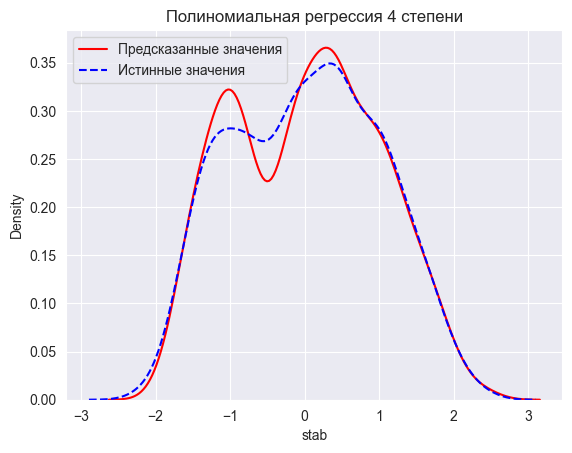

In [128]:
sns.kdeplot(test_predict, label="Предсказанные значения", color="red")
sns.kdeplot(y_test, label="Истинные значения", color="blue", linestyle="--")
plt.title("Полиномиальная регрессия 4 степени")
plt.legend()

С увеличением степени полинома предсказанные значения стали еще ближе к истинным.

Попробуем использовать регуляризацию на полиномиальных моделях.

### Полиномиальная регрессия с регуляризацией

#### Полиномиальная регрессия 2 степени

In [129]:
models_with_regularization = train_models_with_reg(X_poly2_train, y_train, X_poly2_test, y_test)

##### L1 - регуляризация

In [130]:
l1_poly2_models = models_with_regularization["L1"]
l1_poly2_models

{'GridSearch': {'model': Lasso(alpha=0.001), 'best_params': {'alpha': 0.001}},
 'RandomSearch': {'model': Lasso(alpha=0.021209508879201904),
  'best_params': {'alpha': 0.021209508879201904}},
 'Optuna': {'model': Lasso(alpha=0.0010004718039425084),
  'best_params': {'alpha': 0.0010004718039425084}}}

In [131]:
for name_of_method, model_info in l1_poly2_models.items():
    print(name_of_method)
    print(model_info["model"].coef_)

GridSearch
[ 0.00000000e+00  2.01299045e-01  2.09507011e-01  2.05475456e-01
  2.04097726e-01  7.37975560e-04  0.00000000e+00 -5.98879661e-05
 -0.00000000e+00  2.67798063e-01  2.64996883e-01  2.74349742e-01
  2.70943451e-01 -5.85623181e-01 -1.43952151e-01  5.35058884e-02
  5.02939362e-02  5.42054925e-02  5.25626191e-04 -0.00000000e+00
 -9.01352593e-04 -0.00000000e+00  1.03444088e-01 -6.81550976e-03
 -1.82333509e-02 -1.88622766e-02  2.27433209e-02 -1.44315137e-01
  4.87013762e-02  4.75341441e-02 -0.00000000e+00  1.23772112e-03
 -2.94682372e-03  2.13210641e-03 -2.13950614e-02  1.02847951e-01
 -1.62498394e-02 -1.84292805e-02  1.62786784e-02 -1.53049631e-01
  5.09338294e-02 -8.81184547e-04  0.00000000e+00  5.71760149e-03
  0.00000000e+00 -1.83110826e-02 -1.92417016e-02  1.02885574e-01
 -1.84066187e-02  1.99792234e-02 -1.44915426e-01  0.00000000e+00
 -0.00000000e+00  5.29861139e-03 -2.50006547e-03 -1.84488498e-02
 -1.76943892e-02 -1.35907632e-02  1.09342152e-01  2.09470815e-02
  5.66100213e-

После применения L1-регуляризации во всех моделях значения некоторых весов обратились в ноль.

Train Data              \
                                                           R2   MSE  RMSE   
Polynomial regression(deg 2) with L1 (get with ...      0.930 0.073 0.270   
Polynomial regression(deg 2) with L1 (get with ...      0.910 0.092 0.303   
Polynomial regression(deg 2) with L1 (get with ...      0.930 0.073 0.270   
Polynomial regression (deg 2) without regulariz...      0.930 0.072 0.269   

                                                               Test Data  \
                                                     MAE  MAPE        R2   
Polynomial regression(deg 2) with L1 (get with ... 0.205 0.905     0.920   
Polynomial regression(deg 2) with L1 (get with ... 0.239 1.073     0.900   
Polynomial regression(deg 2) with L1 (get with ... 0.205 0.905     0.920   
Polynomial regression (deg 2) without regulariz... 0.204 0.917     0.920   

                                                                            
                                                     MSE  RMSE   MAE  MAPE  
Polynomial regression(deg 2) with L1 (get with ... 0.079 0.281 0.212 1.705  
Polynomial regression(deg 2) with L1 (get with ... 0.096 0.310 0.242 1.882  
Polynomial regression(deg 2) with L1 (get with ... 0.079 0.281 0.212 1.705  
Polynomial regression (deg 2) without regulariz... 0.079 0.280 0.212 1.710

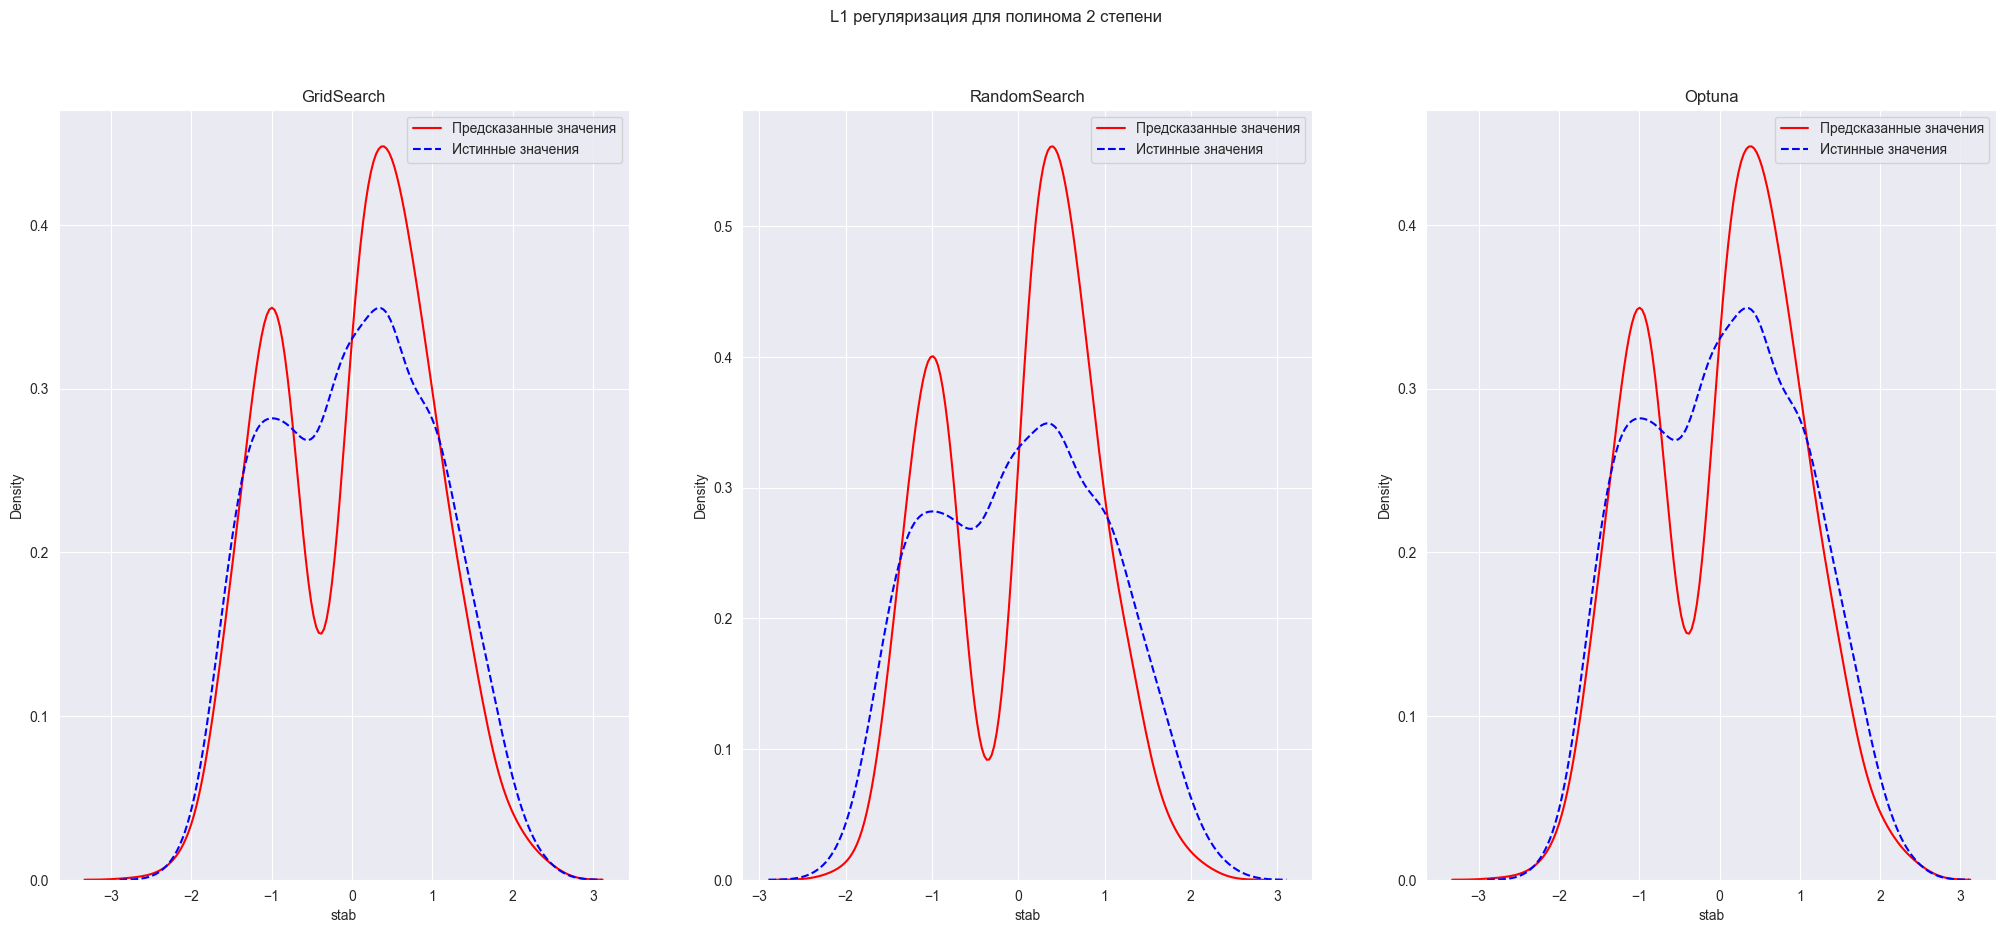

In [132]:
fig, axes = plt.subplots(1, 3, figsize=(25, 10))

for name, ax in zip(names, axes):
    model = l1_poly2_models[name]["model"]

    train_predict = model.predict(X_poly2_train)
    test_predict = model.predict(X_poly2_test)

    sns.kdeplot(test_predict, ax=ax, label="Предсказанные значения", color="red")
    sns.kdeplot(y_test, ax=ax, label="Истинные значения", color="blue", linestyle="--")
    ax.set_title(name)
    ax.legend()

    input_metrics_into_the_table(
        f"Polynomial regression(deg 2) with L1 (get with {name})",
        train_predict, y_train,
        test_predict, y_test,
        train_and_test_comparing
    )

plt.suptitle("L1 регуляризация для полинома 2 степени")

train_and_test_comparing.loc[["Polynomial regression(deg 2) with L1 (get with Optuna)",
                              "Polynomial regression(deg 2) with L1 (get with RandomSearch)",
                              "Polynomial regression(deg 2) with L1 (get with GridSearch)",
                              "Polynomial regression (deg 2) without regularization"]]

По графикам и метрикам видно, что наихудшее приближение к распределению истинных значений делает модель с гиперпараметрами, полученными RandomSearch.

Лучшие метрики показывают модели, обученные с помощью фреймворка Optuna и метода GridSearch. Значения метрик для моделей с регуляризацией и модели без регуляризации практически одни и те же.

##### L2-регуляризация

In [133]:
l2_poly2_models = models_with_regularization["L2"]
l2_poly2_models

{'GridSearch': {'model': Ridge(alpha=0.4498432668969444, max_iter=1000),
  'best_params': {'alpha': 0.4498432668969444}},
 'RandomSearch': {'model': Ridge(alpha=0.4498432668969444, max_iter=1000),
  'best_params': {'alpha': 0.4498432668969444}},
 'Optuna': {'model': Ridge(alpha=0.0010040026606651638),
  'best_params': {'alpha': 0.0010040026606651638}}}

In [134]:
for name_of_method, model_info in l2_poly2_models.items():
    print(name_of_method)
    print(model_info["model"].coef_)

GridSearch
[ 0.00000000e+00  2.04882809e-01  2.13063685e-01  2.09138863e-01
  2.07447064e-01  1.15052389e-04  8.06872038e-04 -8.79881322e-04
 -1.26830478e-04  2.78637160e-01  2.75894350e-01  2.85179162e-01
  2.81706428e-01 -2.94162947e-01 -1.45456804e-01  5.44498100e-02
  5.11169322e-02  5.54612528e-02  1.28674629e-03 -3.68152997e-04
 -1.53962761e-03 -3.27233047e-04  1.03418310e-01 -1.05910807e-02
 -2.16985836e-02 -2.20706187e-02  1.99348652e-02 -1.45562950e-01
  4.93009092e-02  4.88285374e-02 -2.89634254e-04  2.14414669e-03
 -4.50980863e-03  2.86874392e-03 -2.48587433e-02  1.02457503e-01
 -1.95659984e-02 -2.16172595e-02  1.33888690e-02 -1.54886330e-01
  5.16282041e-02 -2.41582335e-03 -8.07908755e-04  5.74950132e-03
 -7.45429981e-04 -2.16155294e-02 -2.27762478e-02  1.02557176e-01
 -2.17384684e-02  1.63643170e-02 -1.45950067e-01 -2.11897113e-04
 -1.34108660e-03  5.94754627e-03 -4.23840684e-03 -2.15287454e-02
 -2.08794369e-02 -1.68512582e-02  1.09884727e-01  1.88829666e-02
  1.54119817e-

После применения L2-регуляризации для всех моделей значения большинства весов уменьшились.

Train Data              \
                                                           R2   MSE  RMSE   
Polynomial regression (deg 2) with L2 (get with...      0.930 0.072 0.269   
Polynomial regression (deg 2) with L2 (get with...      0.930 0.072 0.269   
Polynomial regression (deg 2) with L2 (get with...      0.930 0.072 0.269   
Polynomial regression (deg 2) without regulariz...      0.930 0.072 0.269   

                                                               Test Data  \
                                                     MAE  MAPE        R2   
Polynomial regression (deg 2) with L2 (get with... 0.204 0.917     0.920   
Polynomial regression (deg 2) with L2 (get with... 0.204 0.917     0.920   
Polynomial regression (deg 2) with L2 (get with... 0.204 0.917     0.920   
Polynomial regression (deg 2) without regulariz... 0.204 0.917     0.920   

                                                                            
                                                     MSE  RMSE   MAE  MAPE  
Polynomial regression (deg 2) with L2 (get with... 0.079 0.280 0.212 1.710  
Polynomial regression (deg 2) with L2 (get with... 0.079 0.280 0.212 1.710  
Polynomial regression (deg 2) with L2 (get with... 0.079 0.280 0.212 1.710  
Polynomial regression (deg 2) without regulariz... 0.079 0.280 0.212 1.710

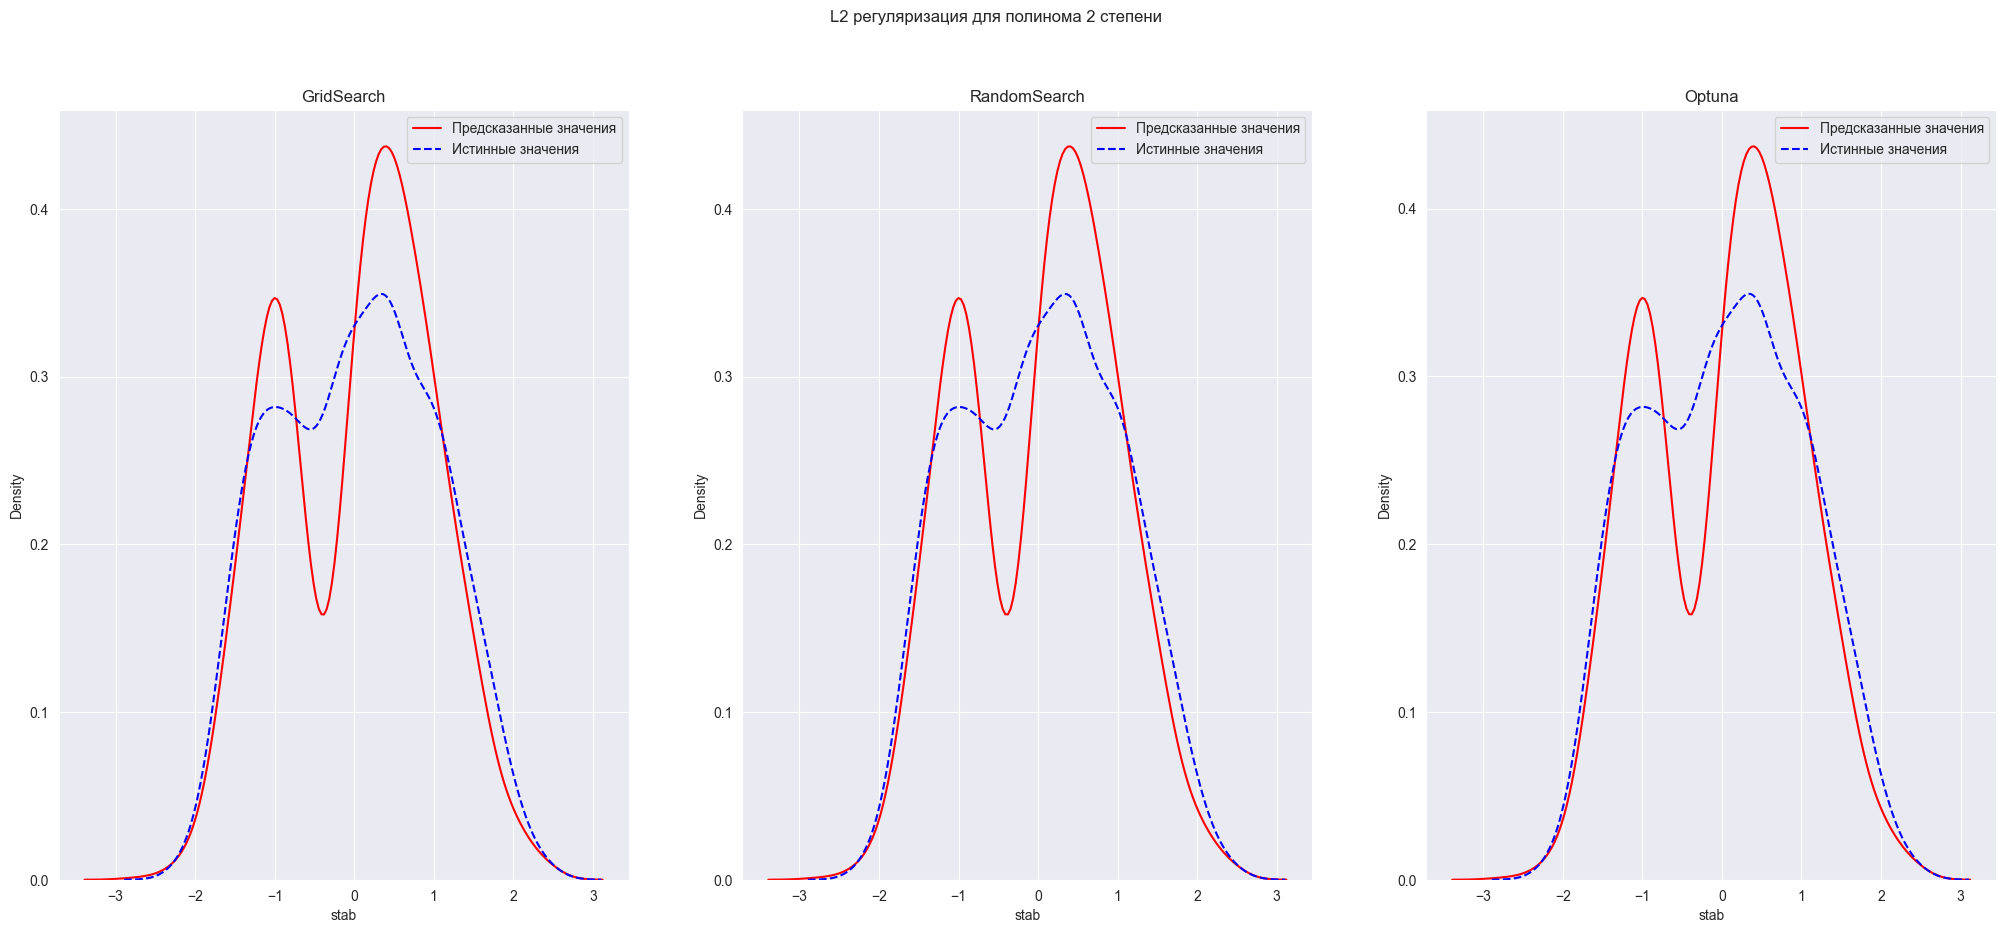

In [135]:
fig, axes = plt.subplots(1, 3, figsize=(25, 10))

for name, ax in zip(names, axes):
    model = l2_poly2_models[name]["model"]

    train_predict = model.predict(X_poly2_train)
    test_predict = model.predict(X_poly2_test)

    sns.kdeplot(test_predict, ax=ax, label="Предсказанные значения", color="red")
    sns.kdeplot(y_test, ax=ax, label="Истинные значения", color="blue", linestyle="--")
    ax.set_title(name)
    ax.legend()

    input_metrics_into_the_table(
        f"Polynomial regression (deg 2) with L2 (get with {name})",
        train_predict, y_train,
        test_predict, y_test,
        train_and_test_comparing
    )

plt.suptitle("L2 регуляризация для полинома 2 степени")

train_and_test_comparing.loc[["Polynomial regression (deg 2) with L2 (get with Optuna)",
                              "Polynomial regression (deg 2) with L2 (get with RandomSearch)",
                              "Polynomial regression (deg 2) with L2 (get with GridSearch)",
                              "Polynomial regression (deg 2) without regularization"]]

Для всех полученных гиперпараметров L2 регуляризация дала значения практически одинаковых метрик.

Стоит отметить, что применение L2 регуляризации практически никак не повлияло на значения метрик в сравнении с моделью без регуляризации.

##### Elastic-Net регуляризация

In [136]:
en_poly2_models = models_with_regularization["EN"]
en_poly2_models

{'GridSearch': {'model': ElasticNet(alpha=0.001, l1_ratio=0.7000000000000001),
  'best_params': {'alpha': 0.001, 'l1_ratio': 0.7000000000000001}},
 'RandomSearch': {'model': ElasticNet(alpha=0.004094915062380427, l1_ratio=0.1),
  'best_params': {'l1_ratio': 0.1, 'alpha': 0.004094915062380427}},
 'Optuna': {'model': ElasticNet(alpha=0.0010001048564148886, l1_ratio=0.11307815187516007),
  'best_params': {'alpha': 0.0010001048564148886,
   'l1_ratio': 0.11307815187516007}}}

In [137]:
for name_of_method, model_info in en_poly2_models.items():
    print(name_of_method)
    print(model_info["model"].coef_)

GridSearch
[ 0.00000000e+00  2.02081362e-01  2.10287839e-01  2.06268323e-01
  2.04827077e-01  4.45431978e-04  0.00000000e+00 -3.81985368e-04
 -1.09839753e-04  2.70631502e-01  2.67750092e-01  2.77151784e-01
  2.73697706e-01 -3.19636693e-01 -1.44322881e-01  5.38759756e-02
  5.06455992e-02  5.46557741e-02  8.72988351e-04 -0.00000000e+00
 -1.01246458e-03 -0.00000000e+00  1.03515396e-01 -7.78725527e-03
 -1.91323009e-02 -1.96980175e-02  2.25712100e-02 -1.44640793e-01
  4.89777637e-02  4.80137088e-02 -0.00000000e+00  1.60705487e-03
 -3.35050470e-03  2.40059206e-03 -2.23223253e-02  1.02862747e-01
 -1.71237650e-02 -1.92678094e-02  1.61057919e-02 -1.53528292e-01
  5.12497392e-02 -9.90822927e-04  0.00000000e+00  5.92279515e-03
  0.00000000e+00 -1.91681160e-02 -2.01486267e-02  1.02895650e-01
 -1.92703754e-02  1.96135896e-02 -1.45170728e-01  0.00000000e+00
 -2.74901755e-04  5.53494473e-03 -2.95428781e-03 -1.92659201e-02
 -1.85102517e-02 -1.44395276e-02  1.09571858e-01  2.09801675e-02
  1.64849601e-

При применении Elastic Net регуляризации значения большинства весов уменьшились, некоторые обратились в ноль.

Train Data              \
                                                           R2   MSE  RMSE   
Polynomial regression (deg 2) with Elastic Net ...      0.930 0.072 0.269   
Polynomial regression (deg 2) with Elastic Net ...      0.930 0.073 0.270   
Polynomial regression (deg 2) with Elastic Net ...      0.930 0.073 0.270   
Polynomial regression (deg 2) without regulariz...      0.930 0.072 0.269   

                                                               Test Data  \
                                                     MAE  MAPE        R2   
Polynomial regression (deg 2) with Elastic Net ... 0.204 0.913     0.920   
Polynomial regression (deg 2) with Elastic Net ... 0.205 0.904     0.920   
Polynomial regression (deg 2) with Elastic Net ... 0.204 0.907     0.920   
Polynomial regression (deg 2) without regulariz... 0.204 0.917     0.920   

                                                                            
                                                     MSE  RMSE   MAE  MAPE  
Polynomial regression (deg 2) with Elastic Net ... 0.079 0.280 0.212 1.708  
Polynomial regression (deg 2) with Elastic Net ... 0.079 0.281 0.213 1.705  
Polynomial regression (deg 2) with Elastic Net ... 0.079 0.281 0.212 1.707  
Polynomial regression (deg 2) without regulariz... 0.079 0.280 0.212 1.710

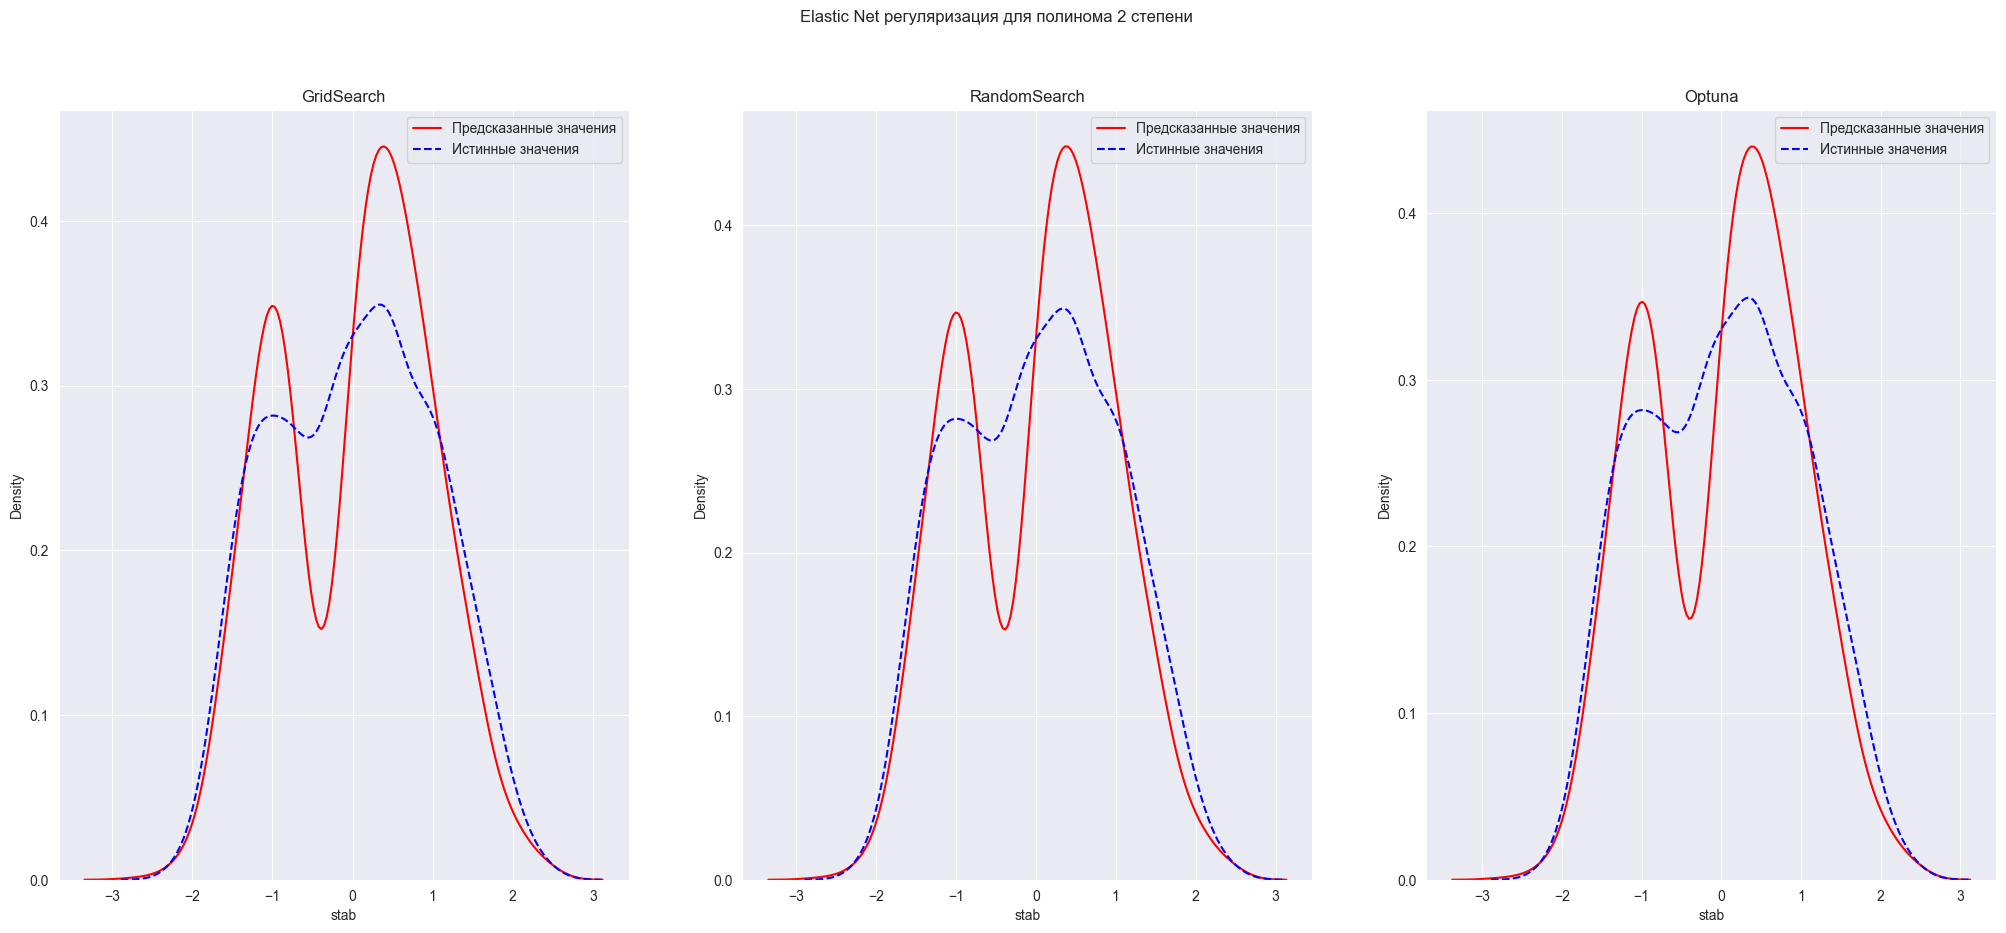

In [138]:
fig, axes = plt.subplots(1, 3, figsize=(25, 10))

for name, ax in zip(names, axes):
    model = en_poly2_models[name]["model"]

    train_predict = model.predict(X_poly2_train)
    test_predict = model.predict(X_poly2_test)

    sns.kdeplot(test_predict, ax=ax, label="Предсказанные значения", color="r")
    sns.kdeplot(y_test, ax=ax, label="Истинные значения", color="blue", linestyle="--")
    ax.set_title(name)
    ax.legend()

    input_metrics_into_the_table(
        f"Polynomial regression (deg 2) with Elastic Net (get with {name})",
        train_predict, y_train,
        test_predict, y_test,
        train_and_test_comparing
    )

plt.suptitle("Elastic Net регуляризация для полинома 2 степени")

train_and_test_comparing.loc[["Polynomial regression (deg 2) with Elastic Net (get with Optuna)",
                              "Polynomial regression (deg 2) with Elastic Net (get with RandomSearch)",
                              "Polynomial regression (deg 2) with Elastic Net (get with GridSearch)",
                              "Polynomial regression (deg 2) without regularization"]]

Применение Elastic Net регуляризации никак не повлияло на показатели метрик в сравнении с моделью без регуляризации.

#### Полиномиальная регрессия 3 и 4 степени

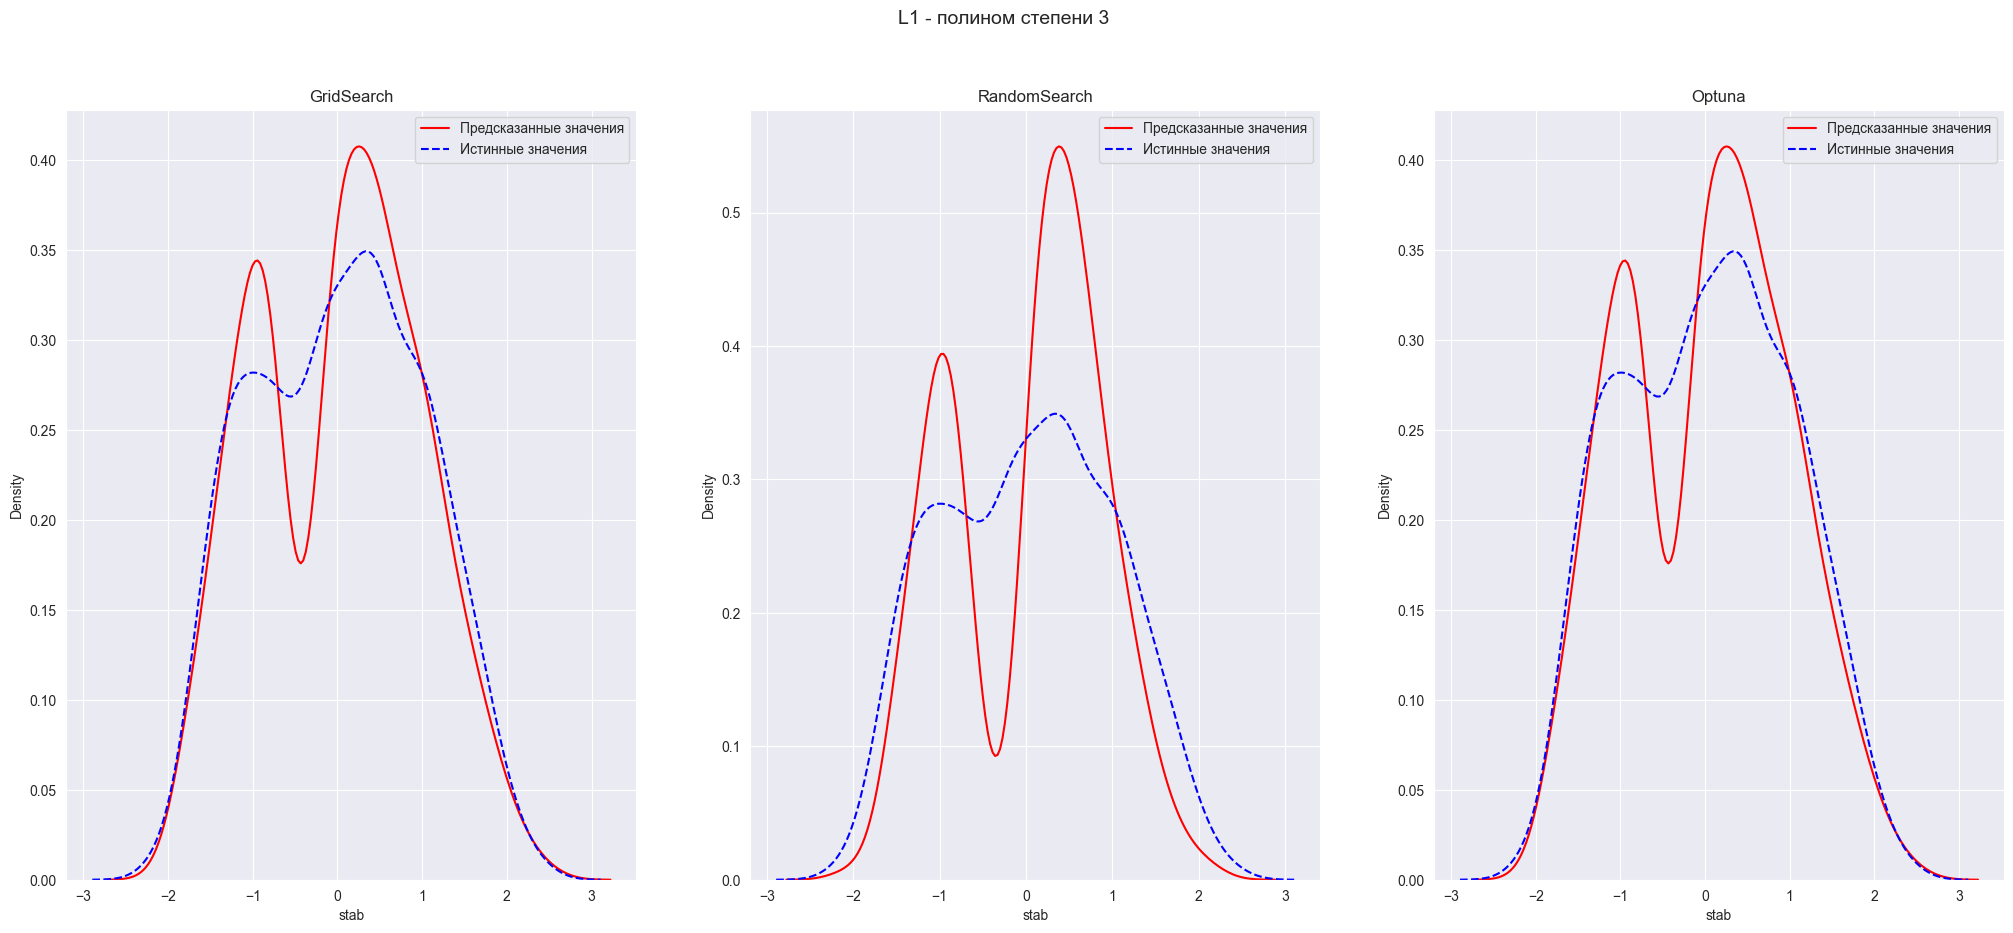

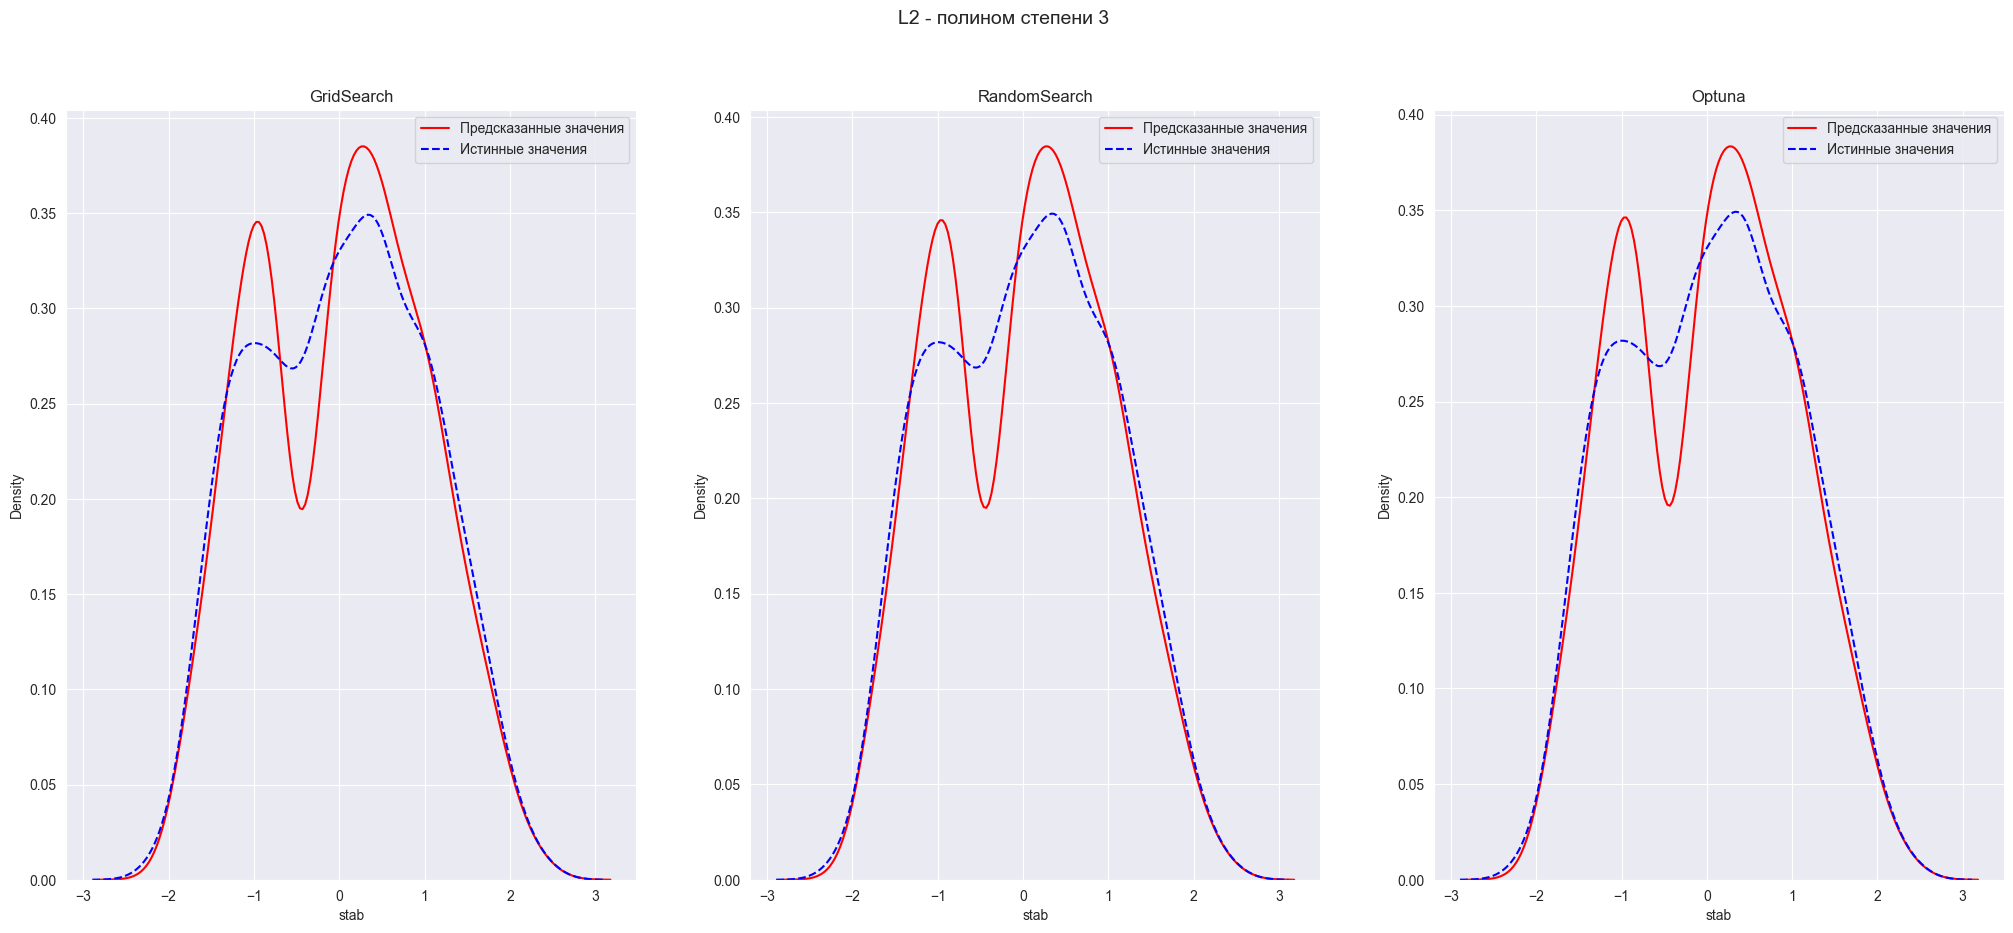

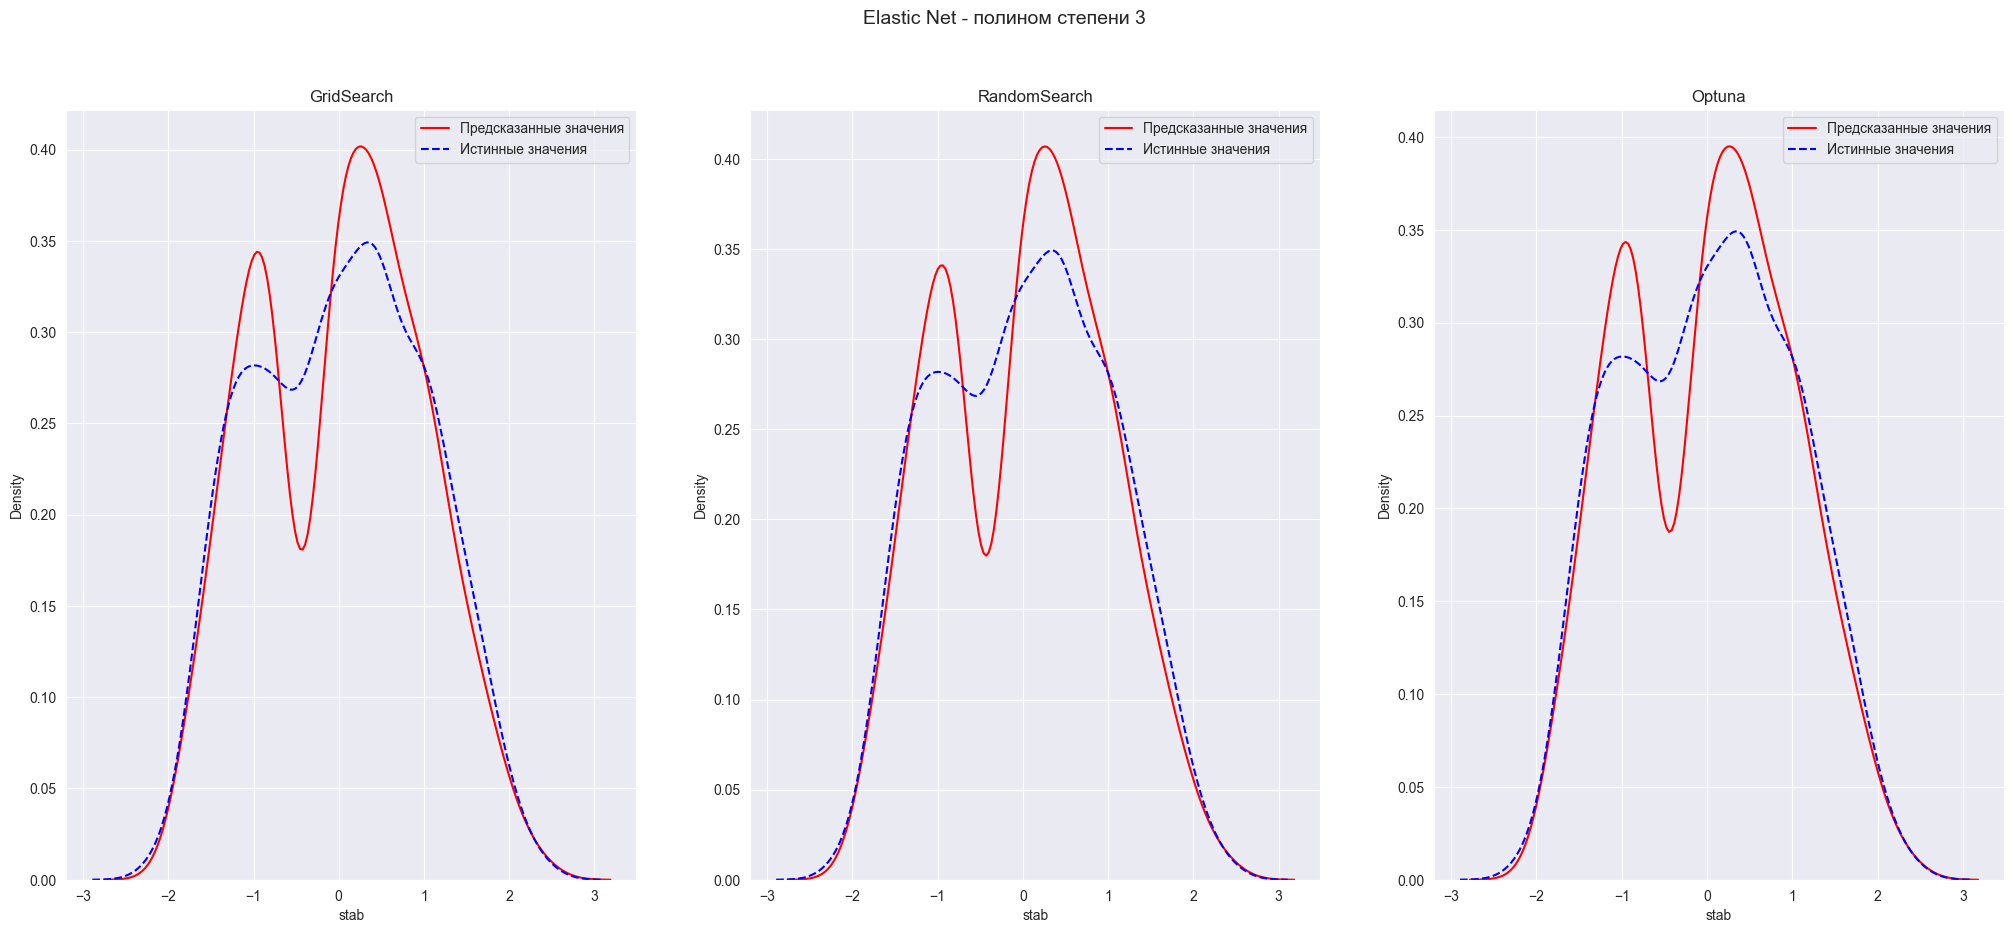

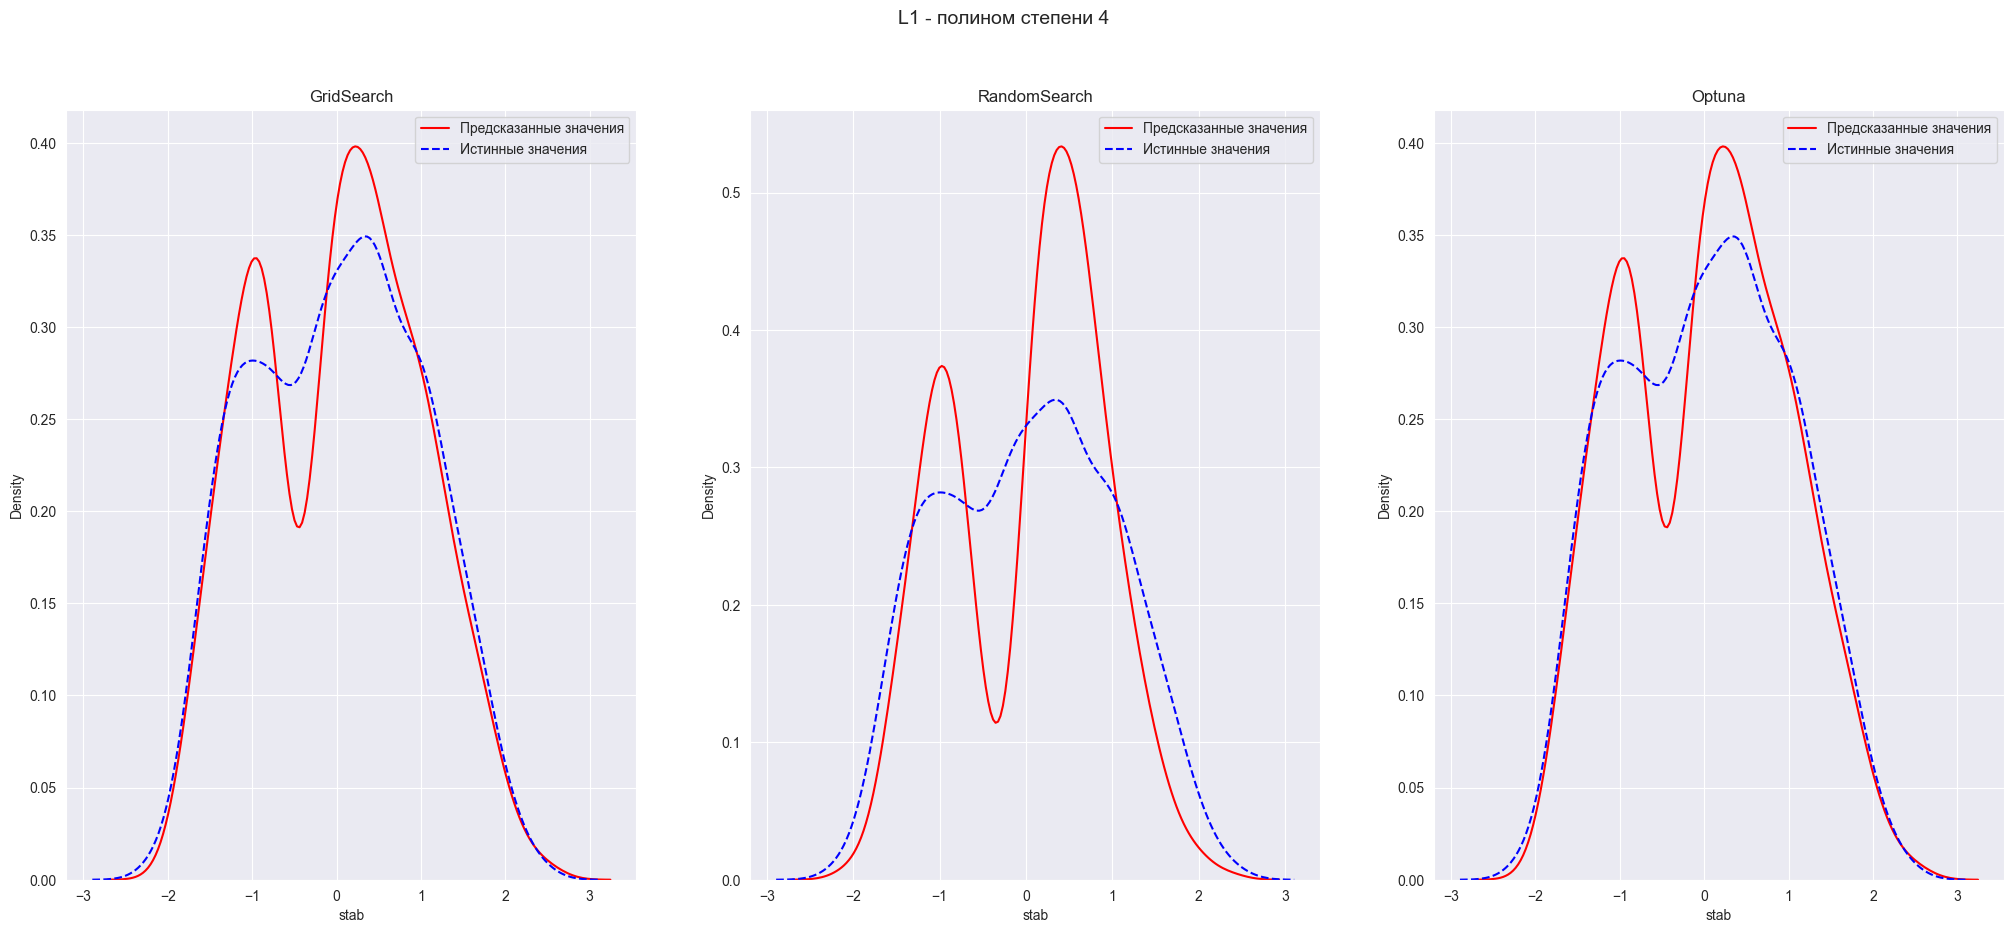

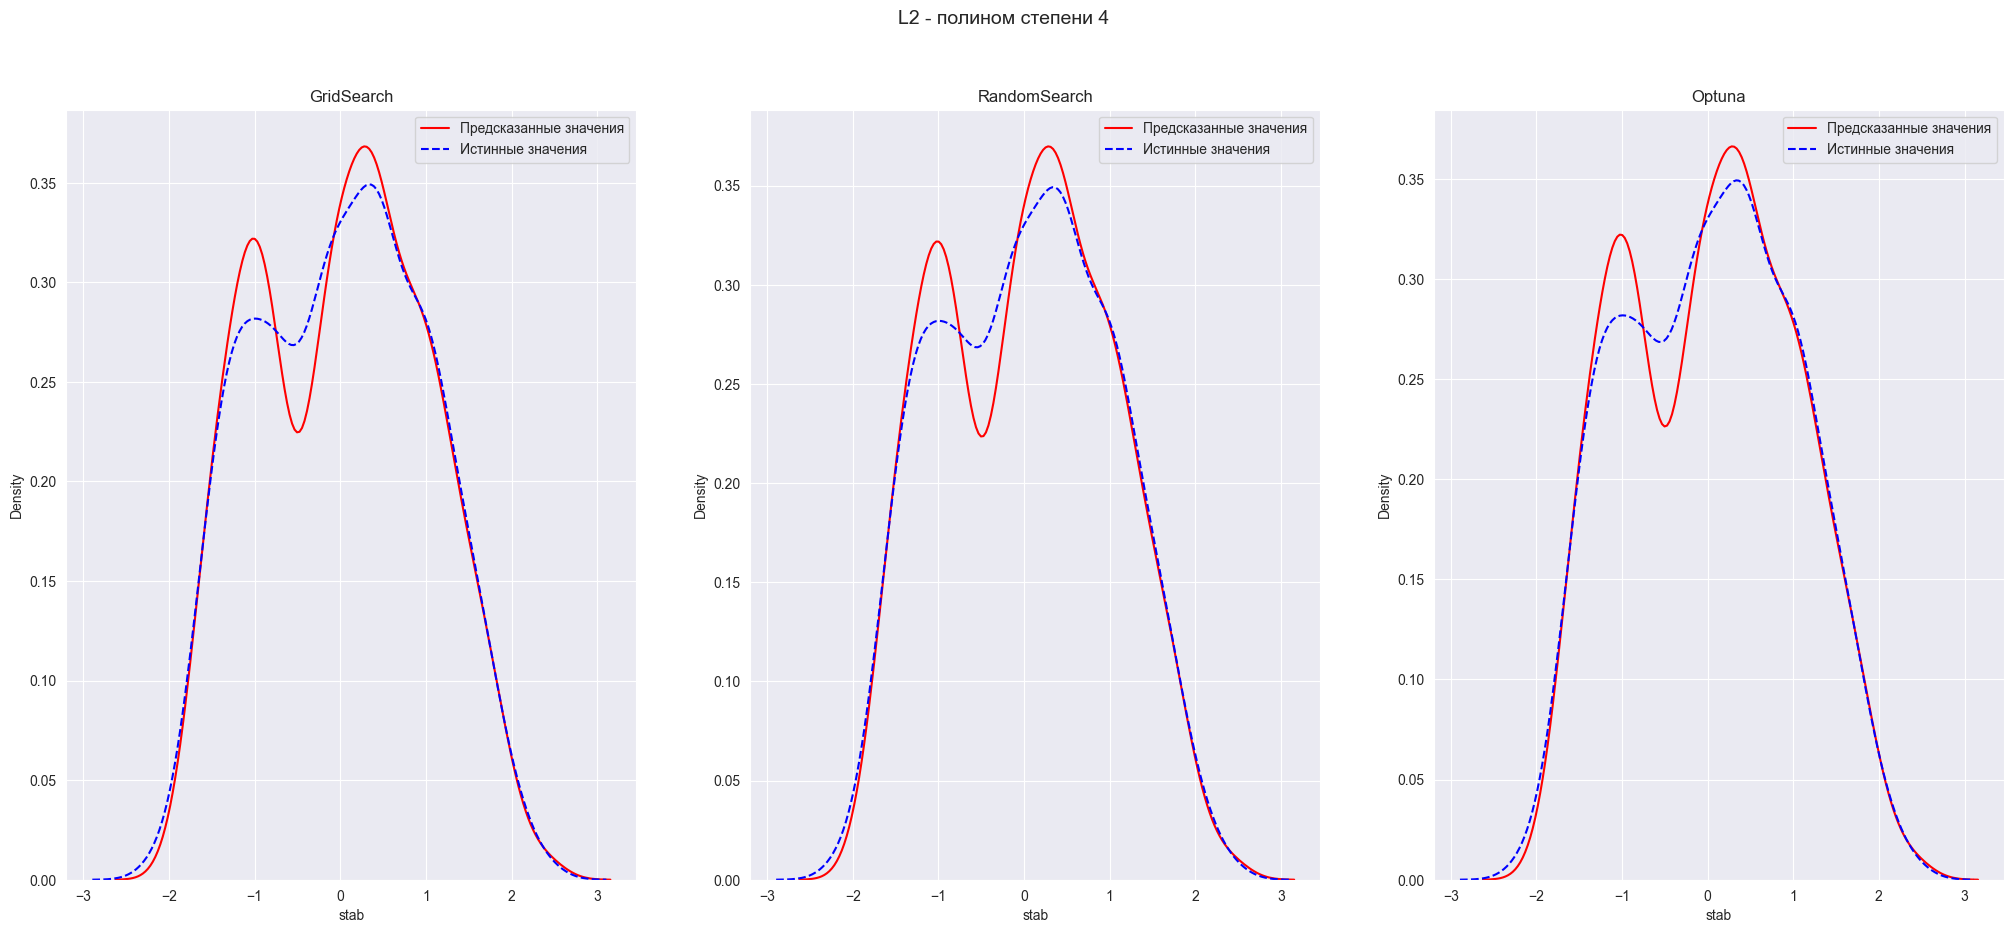

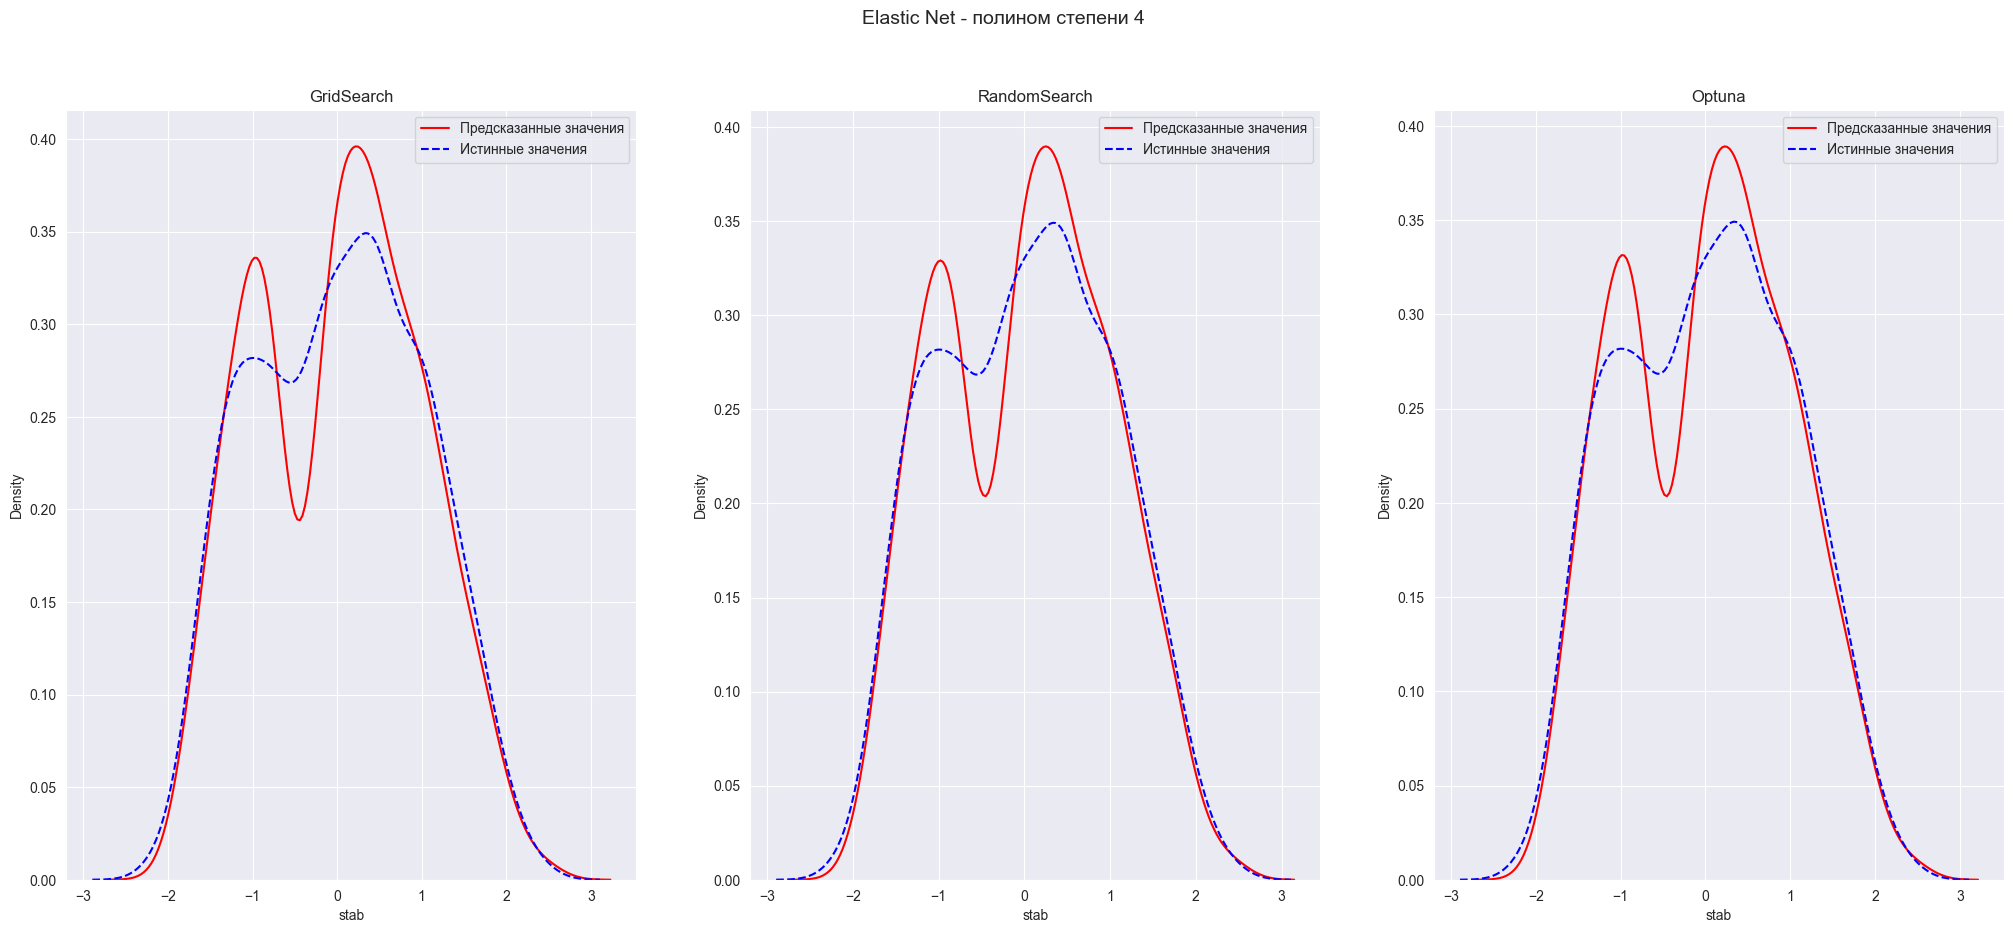

In [55]:
polynomial_X = [(X_poly3_train, X_poly3_test), (X_poly4_train, X_poly4_test)]
results = {}
for i, (X_poly_train, X_poly_test) in enumerate(polynomial_X, start=3):
    degree = i

    models_with_regularization = train_models_with_reg(
        X_poly_train, y_train,
        X_poly_test, y_test
    )

    results[degree] = models_with_regularization

    l1_models = models_with_regularization["L1"]

    fig, axes = plt.subplots(1, 3, figsize=(25, 10))
    fig.suptitle(f"L1 - полином степени {degree}", fontsize=14)


    for name, ax in zip(names, axes):

        model = l1_models[name]["model"]

        train_pred = model.predict(X_poly_train)
        test_pred  = model.predict(X_poly_test)

        sns.kdeplot(test_pred, ax=ax, label="Предсказанные значения", color="red")
        sns.kdeplot(y_test, ax=ax, label="Истинные значения", color="blue", linestyle="--")
        ax.set_title(name)
        ax.legend()

        key = f"Polynomial regression (deg {degree}) with L1 ({name})"
        input_metrics_into_the_table(
            key, train_pred, y_train, test_pred, y_test, train_and_test_comparing
        )



    l2_models = models_with_regularization["L2"]

    fig, axes = plt.subplots(1, 3, figsize=(25, 10))
    fig.suptitle(f"L2 - полином степени {degree}", fontsize=14)


    for name, ax in zip(names, axes):
        model = l2_models[name]["model"]

        train_pred = model.predict(X_poly_train)
        test_pred  = model.predict(X_poly_test)

        sns.kdeplot(test_pred, ax=ax, label="Предсказанные значения", color="red")
        sns.kdeplot(y_test, ax=ax, label="Истинные значения", color="blue", linestyle="--")
        ax.set_title(name)
        ax.legend()

        key = f"Polynomial regression (deg {degree}) with L2 ({name})"
        input_metrics_into_the_table(
            key, train_pred, y_train, test_pred, y_test, train_and_test_comparing
        )



    en_models = models_with_regularization["EN"]

    fig, axes = plt.subplots(1, 3, figsize=(25, 10))
    fig.suptitle(f"Elastic Net - полином степени {degree}", fontsize=14)


    for name, ax in zip(names, axes):
        model = en_models[name]["model"]

        train_pred = model.predict(X_poly_train)
        test_pred  = model.predict(X_poly_test)

        sns.kdeplot(test_pred, ax=ax, label="Предсказанные значения", color="red")
        sns.kdeplot(y_test, ax=ax, label="Истинные значения", color="blue", linestyle="--")
        ax.set_title(name)
        ax.legend()

        key = f"Polynomial regression (deg {degree}) with Elastic Net ({name})"
        input_metrics_into_the_table(
            key, train_pred, y_train, test_pred, y_test, train_and_test_comparing
        )



По графикам видно, что модель полиномиальной регрессии 4 степени работает лучшим образом. Посмотрим на значения метрик в общей таблице.

## Вывод

### Выбор лучшей модели

In [61]:
train_and_test_comparing.sort_values(by=("Test Data", "R2"), ascending=False)

Train Data              \
                                                           R2   MSE  RMSE   
Polynomial regression (deg 4) with L2 (Optuna)          0.980 0.018 0.134   
Polynomial regression (deg 4) with L1 (Optuna)          0.980 0.023 0.152   
Polynomial regression (deg 4) with L2 (GridSearch)      0.980 0.018 0.135   
Polynomial regression (deg 4) without regulariz...      0.980 0.018 0.134   
Polynomial regression (deg 4) with Elastic Net ...      0.980 0.021 0.144   
Polynomial regression (deg 4) with Elastic Net ...      0.980 0.021 0.145   
Polynomial regression (deg 4) with Elastic Net ...      0.980 0.022 0.150   
Polynomial regression (deg 4) with L1 (GridSearch)      0.980 0.023 0.152   
Polynomial regression (deg 4) with L2 (RandomSe...      0.980 0.018 0.135   
Polynomial regression (deg 3) with L2 (RandomSe...      0.970 0.034 0.183   
Polynomial regression (deg 3) with L1 (GridSearch)      0.970 0.035 0.187   
Polynomial regression (deg 3) with L2 (GridSearch)      0.970 0.034 0.183   
Polynomial regression (deg 3) with L1 (Optuna)          0.970 0.035 0.187   
Polynomial regression (deg 3) without regulariz...      0.970 0.034 0.183   
Polynomial regression (deg 3) with Elastic Net ...      0.970 0.035 0.186   
Polynomial regression (deg 3) with Elastic Net ...      0.970 0.034 0.184   
Polynomial regression (deg 3) with L2 (Optuna)          0.970 0.034 0.183   
Polynomial regression (deg 3) with Elastic Net ...      0.970 0.034 0.185   
Polynomial regression (deg 2) without regulariz...      0.930 0.072 0.269   
Polynomial regression(deg 2) with L1 (get with ...      0.930 0.073 0.270   
Polynomial regression(deg 2) with L1 (get with ...      0.930 0.073 0.270   
Polynomial regression (deg 2) with Elastic Net ...      0.930 0.072 0.269   
Polynomial regression (deg 2) with Elastic Net ...      0.930 0.073 0.270   
Polynomial regression (deg 2) with Elastic Net ...      0.930 0.073 0.270   
Polynomial regression (deg 2) with L2 (get with...      0.930 0.072 0.269   
Polynomial regression (deg 2) with L2 (get with...      0.930 0.072 0.269   
Polynomial regression (deg 2) with L2 (get with...      0.930 0.072 0.269   
Polynomial regression (deg 3) with L1 (RandomSe...      0.920 0.081 0.285   
Polynomial regression (deg 4) with L1 (RandomSe...      0.910 0.090 0.300   
Polynomial regression(deg 2) with L1 (get with ...      0.910 0.092 0.303   
Linear regression with Lasso regularization             0.820 0.184 0.429   
Linear regression without regularization                0.820 0.184 0.429   
Linear regression with Elastic Net (get with Gr...      0.820 0.184 0.429   
Linear regression with Ridge regularization             0.820 0.184 0.429   
Linear regression with Elastic Net (get with Ra...      0.820 0.184 0.429   
Linear regression with Elastic Net (get with Op...      0.820 0.184 0.429   

                                                               Test Data  \
                                                     MAE  MAPE        R2   
Polynomial regression (deg 4) with L2 (Optuna)     0.092 0.341     0.970   
Polynomial regression (deg 4) with L1 (Optuna)     0.104 0.386     0.970   
Polynomial regression (deg 4) with L2 (GridSearch) 0.092 0.338     0.970   
Polynomial regression (deg 4) without regulariz... 0.092 0.342     0.970   
Polynomial regression (deg 4) with Elastic Net ... 0.099 0.367     0.970   
Polynomial regression (deg 4) with Elastic Net ... 0.098 0.368     0.970   
Polynomial regression (deg 4) with Elastic Net ... 0.102 0.380     0.970   
Polynomial regression (deg 4) with L1 (GridSearch) 0.104 0.386     0.970   
Polynomial regression (deg 4) with L2 (RandomSe... 0.093 0.337     0.960   
Polynomial regression (deg 3) with L2 (RandomSe... 0.128 0.578     0.960   
Polynomial regression (deg 3) with L1 (GridSearch) 0.131 0.581     0.960   
Polynomial regression (deg 3) with L2 (GridSearch) 0.128 0.578     0.960   
Polynomial regression (deg 3) with L1 (Optuna)     0.131 0.5

Наилучшей обученной моделью оказалась модель полиномиальной регрессии 4 степени с регуляризацией L1 (Optuna). Эта модель обладает лучшими метриками среди обученных моделей:
* R2: 0.970
* RMSE: 0.182
* MSE: 0.033,
* MAPE: 0.588,
* MAE: 0.122

В целом лучше всего на данных себя проявили модели полиномиальной регрессии. Причем с увеличением степени полинома модель давала предсказания, более близкие к истинным.


### Восстановление уравнения регрессии для лучшей модели

In [139]:
best_model = results[4]["L1"]["Optuna"]["model"]

b0 = best_model.intercept_
coefs = model.coef_

features = poly4.get_feature_names_out()


regression_eq = [f"{b0:.6f}"]

for feature, coef in zip(features, coefs):
    if coef != 0:
        sign = " + " if coef >=0 else " - "
        coef = abs(coef)
        regression_eq.append(f"{sign}{coef:.6f} * {feature}")

equation = "".join(regression_eq)
equation

'1.016035 + 0.203456 * tau1 + 0.211639 * tau2 + 0.207699 * tau3 + 0.206126 * tau4 + 0.000258 * p2 - 0.000749 * p3 - 0.000192 * p4 + 0.276000 * g1 + 0.273114 * g2 + 0.282428 * g3 + 0.278931 * g4 - 0.297357 * stabf - 0.145052 * tau1^2 + 0.054677 * tau1 tau2 + 0.051399 * tau1 tau3 + 0.055610 * tau1 tau4 + 0.001693 * tau1 p1 - 0.001233 * tau1 p3 + 0.103723 * tau1 g1 - 0.009689 * tau1 g2 - 0.020819 * tau1 g3 - 0.021263 * tau1 g4 + 0.022578 * tau1 stabf - 0.145223 * tau2^2 + 0.049583 * tau2 tau3 + 0.048993 * tau2 tau4 + 0.002267 * tau2 p2 - 0.004233 * tau2 p3 + 0.002883 * tau2 p4 - 0.024064 * tau2 g1 + 0.102894 * tau2 g2 - 0.018750 * tau2 g3 - 0.020828 * tau2 g4 + 0.016093 * tau2 stabf - 0.154430 * tau3^2 + 0.051911 * tau3 tau4 - 0.001126 * tau3 p1 + 0.006328 * tau3 p3 - 0.020800 * tau3 g1 - 0.021892 * tau3 g2 + 0.102973 * tau3 g3 - 0.020885 * tau3 g4 + 0.019239 * tau3 stabf - 0.145653 * tau4^2 - 0.000984 * tau4 p2 + 0.005933 * tau4 p3 - 0.003910 * tau4 p4 - 0.020792 * tau4 g1 - 0.020083 * t